# ATAC logFC

In [43]:
import pandas as pd
import numpy as np
from scipy.stats import lognorm
def compute_atac_pvalues_no_fdr(
    df_pos_diff: np.ndarray,
    df_neg_diff: np.ndarray,
    index_csv_path: str
) -> pd.DataFrame:
    """
    Function to compute SHAP effect sizes and p-values for SNPs using new data inputs.

    Parameters
    ----------
    df_pos_diff : np.ndarray
        Array of SHAP effect differences from the positive set.
    df_neg_diff : np.ndarray
        Array of SHAP effect differences from the negative set (null distribution).
    index_csv_path : str
        Path to the CSV file containing at least an 'index' column.

    Returns
    -------
    pd.DataFrame
        Columns: ['index', 'SNP_SHAP_Effect_Size', 'p_value']
    """

    # Ensure input arrays have the correct length
    N = 855
    if len(df_pos_diff) != N or len(df_neg_diff) != N:
        raise ValueError(f"Expected {N} values for both positive and negative datasets, "
                         f"but got {len(df_pos_diff)} and {len(df_neg_diff)}.")

    # Compute absolute SHAP effect sizes
    summed_values = np.abs(df_pos_diff)
    summed_values_null = np.abs(df_neg_diff)
    
    # ----------------------------------------
    # Handle Zeroes in `summed_values_null`
    # ----------------------------------------
    min_nonzero = np.min(summed_values_null[summed_values_null > 0])  # Find smallest nonzero value
    summed_values_null[summed_values_null == 0] = min_nonzero  # Replace all zeros

    # ----------------------------------------
    # Fit Lognormal Distribution to Null
    # ----------------------------------------
    shape_ln, loc_ln, scale_ln = lognorm.fit(summed_values_null, floc=0)

    # ----------------------------------------
    # Compute P-values (Upper Tail)
    # ----------------------------------------
    pvals = 1 - lognorm.cdf(summed_values, shape_ln, loc_ln, scale_ln)

    # ----------------------------------------
    # Build and Return Results DataFrame
    # ----------------------------------------
    df_index = pd.read_csv(index_csv_path, index_col=0)
    sign_values = np.where(df_pos_diff > 0, 1, -1)

    df_result = pd.DataFrame({
        'SNP_SHAP_Effect_Size': summed_values,
        'p_value': pvals,
        'sign':sign_values,
        'SNP_SHAP_diff': df_pos_diff
    })
    df_result.index = df_index.index[:N]  # Ensure index matches

    # Log Summary
    print(f"[LOGNORMAL FIT] shape={shape_ln:.4f}, loc={loc_ln:.4f}, scale={scale_ln:.4f}")
    print(f"Total data points: {N}")

    return df_result

folders = [
    'fullard_putamen-model-best',
    'fullard_DLPFC-model-best',
    'fullard_hippocampus-model-best',
    'H1_IFNB-model-best',
    'H1_resting-model',
    'HEK293_ATAC_high_depth0729',
    'HEK293T_ATAC',
    'Mouse_Cortex_AgeB-model',
    'Mouse_Cortex_AgeC-model',
    'Mouse_Striatum_AgeB',
    'Mouse_Striatum_AgeC',
    'THP1_IFNB-Calvin',
    'THP1_IFNG-Calvin',
    'THP1_LPSIFNG-Calvin',
    'THP1_monocyte0729',
    'THP1_Naive-Calvin',
    'WTC11_IFNB',
    'WTC11_resting',
]

pairs = []
for f in folders:
    pairs.append((
        f'/media/zihengc/T7/THP1_machinelearning/mpra3_prediction/prediction/10kbmodels_20250110_MPRA_500bp_SNPCenter_genomic_sequences/{f}_20240826_MPRA_500bp_SNPandControl_500bpbarcodes_one.csv',
        f'/media/zihengc/T7/THP1_machinelearning/mpra3_prediction/prediction/10kbmodels_20250110_MPRA_500bp_SNPCenter_genomic_sequences_negative/{f}_20240826_MPRA_500bp_SNPandControl_500bpbarcodes_one.csv',
        f
    ))

index_csv_path = '/media/zihengc/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_20250103.csv'

all_p_values = pd.DataFrame()
all_shap_effect = pd.DataFrame()
all_shap_sign = pd.DataFrame()
all_pos_diff = pd.DataFrame()
all_pos_majorminor_logfc = pd.DataFrame()
all_predicted_values = pd.DataFrame()
for (file1, file2, model) in pairs:
    # Load and process the positive dataset
    df_pos = pd.read_csv(file1, header=None)
    df_pos = df_pos.groupby(df_pos.index // 2).mean()
    df_pos_diff = np.array(df_pos.loc[:854][0]) - np.array(df_pos.loc[855:][0])
    df_pos_major = df_pos[0][:855]
    # Load and process the negative dataset
    df_neg = pd.read_csv(file2, header=None)
    df_neg = df_neg.groupby(df_neg.index // 2).mean()
    df_neg_diff = np.array(df_neg.loc[:854][0]) - np.array(df_neg.loc[855:][0])
    df_pos_minor = df_pos[0][855:]
    # Compute SHAP p-values and effect sizes
    df_result = compute_atac_pvalues_no_fdr(
        df_pos_diff=df_pos_diff,
        df_neg_diff=df_neg_diff,
        index_csv_path=index_csv_path)

    # Store results
    all_p_values[model] = df_result['p_value']
    all_shap_effect[model] = df_result['SNP_SHAP_Effect_Size']
    all_shap_sign[model] = df_result['sign']
    all_pos_diff[model] = df_result['SNP_SHAP_diff']

    min_nonzero_major = np.min(df_pos_major[df_pos_major > 0])  # Find smallest nonzero value
    min_nonzero_minor = np.min(df_pos_minor[df_pos_minor > 0])  # Find smallest nonzero value
    df_pos_major[df_pos_major <= 0] = np.min(min_nonzero_major)
    df_pos_minor[df_pos_minor <= 0] = np.min(min_nonzero_minor )
    all_pos_majorminor_logfc[model] = np.log2(np.array(df_pos_major)/np.array(df_pos_minor))
    all_pos_majorminor_logfc.index = df_result.index
    all_predicted_values[model+"_major"] = np.array(df_pos.loc[:854][0])
    all_predicted_values[model+"_minor"] = np.array(df_pos.loc[855:][0])
    all_predicted_values.index = df_result.index

df_index = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_20250103.csv' ,index_col=0)
df_index["rsid_gene_label"] = df_index['rsID']+"("+df_index['closest_protein_coding_gene_TSS']+") "+df_index['hierarchical_label']
df_index_unique = df_index.drop_duplicates(subset=['rsID'])
unique_snp = df_index_unique.index

all_p_values_unique = all_p_values.loc[unique_snp]
all_shap_sign_unique = all_shap_sign.loc[unique_snp]
all_shap_effect_unique = all_shap_effect.loc[unique_snp]
all_pos_diff_unique = all_pos_diff.loc[unique_snp]
all_pos_majorminor_logfc_unique = all_pos_majorminor_logfc.loc[unique_snp]
all_predicted_values_unique = all_predicted_values.loc[unique_snp]

all_p_values_unique.index = df_index_unique["rsid_gene_label"]
all_shap_sign_unique.index = df_index_unique["rsid_gene_label"]
all_shap_effect_unique.index = df_index_unique["rsid_gene_label"]
all_pos_diff_unique.index = df_index_unique["rsid_gene_label"]
all_pos_majorminor_logfc_unique.index = df_index_unique["rsid_gene_label"]
all_predicted_values_unique.index = df_index_unique["rsid_gene_label"]
df_signed_neg_log_p_atac = -np.log10(all_p_values_unique)*all_shap_sign_unique

[LOGNORMAL FIT] shape=2.3914, loc=0.0000, scale=0.0425
Total data points: 855
[LOGNORMAL FIT] shape=2.3321, loc=0.0000, scale=0.0323
Total data points: 855
[LOGNORMAL FIT] shape=2.4897, loc=0.0000, scale=0.0304
Total data points: 855
[LOGNORMAL FIT] shape=2.2278, loc=0.0000, scale=0.0439
Total data points: 855
[LOGNORMAL FIT] shape=2.3860, loc=0.0000, scale=0.0427
Total data points: 855
[LOGNORMAL FIT] shape=2.3694, loc=0.0000, scale=0.0203
Total data points: 855
[LOGNORMAL FIT] shape=2.1445, loc=0.0000, scale=0.0667
Total data points: 855
[LOGNORMAL FIT] shape=2.6758, loc=0.0000, scale=0.0331
Total data points: 855
[LOGNORMAL FIT] shape=2.3930, loc=0.0000, scale=0.0580
Total data points: 855
[LOGNORMAL FIT] shape=2.4502, loc=0.0000, scale=0.0576
Total data points: 855
[LOGNORMAL FIT] shape=2.2183, loc=0.0000, scale=0.0616
Total data points: 855
[LOGNORMAL FIT] shape=2.4455, loc=0.0000, scale=0.0474
Total data points: 855
[LOGNORMAL FIT] shape=2.3168, loc=0.0000, scale=0.0519
Total dat

# SHAP LOGFC

In [44]:
import numpy as np
def compute_shap_pvalues_no_fdr(
    npz_file_path_major_minor: str,
    npz_file_path_major_minor_null: str,
    index_csv_path: str,
    distance: int = 0
) -> pd.DataFrame:
    """
    Function to compute SHAP effect sizes and p-values for SNPs.

    Parameters
    ----------
    npz_file_path_major_minor : str
        Path to the first .npz file (major/minor).
    npz_file_path_major_minor_null : str
        Path to the second .npz file (major/minor) for the null distribution.
    index_csv_path : str
        Path to the CSV file containing at least an 'index' column.
    distance : int, optional
        Flanking distance around position 250 (default=0 => only position 250).

    Returns
    -------
    pd.DataFrame
        Columns: ['index', 'SNP_SHAP_Effect_Size', 'p_value', 'sign']
    """

    def split_shap(shap_scores_squeezed, distance=0):
        """Splits SHAP values into left, SNP, and right based on distance."""
        if distance != 0:
            left = shap_scores_squeezed[:, :, (250 - distance):250]
            snp = shap_scores_squeezed[:, :, 250]
            right = shap_scores_squeezed[:, :, 251:(251 + distance)]
            return left, snp, right
        else:
            snp = shap_scores_squeezed[:, :, 250]
            return None, snp, None

    # ----------------------------------------
    # 1. Load SHAP arrays
    # ----------------------------------------
    shap_data_1 = np.load(npz_file_path_major_minor)
    shap_data_2 = np.load(npz_file_path_major_minor_null)

    shap_scores_squeezed_1 = np.squeeze(shap_data_1['arr_0'])
    shap_scores_squeezed_2 = np.squeeze(shap_data_2['arr_0'])

    # Number of SNPs
    N = 855

    # Extract major/minor SHAP values
    shap_scores_major_1 = shap_scores_squeezed_1[:N, :, :]
    shap_scores_minor_1 = shap_scores_squeezed_1[N:, :, :]
    shap_scores_major_2 = shap_scores_squeezed_2[:N, :, :]
    shap_scores_minor_2 = shap_scores_squeezed_2[N:, :, :]

    # ----------------------------------------
    # 2. Compute SHAP Differences
    # ----------------------------------------
    left_major, snp_major, right_major = split_shap(shap_scores_major_1, distance)
    left_minor, snp_minor, right_minor = split_shap(shap_scores_minor_1, distance)

    left_major_null, snp_major_null, right_major_null = split_shap(shap_scores_major_2, distance)
    left_minor_null, snp_minor_null, right_minor_null = split_shap(shap_scores_minor_2, distance)

    # For convenience, define a helper function for differences
    def compute_diff_and_null_diff(left_ma, left_mi, right_ma, right_mi, snp_ma, snp_mi):
        """Compute shap_scores_diff and shap_scores_diff_null."""
        if left_ma is not None:
            left_diff = np.sum(left_ma - left_mi, axis=1)
            right_diff = np.sum(right_ma - right_mi, axis=1)
            snp_diff = (np.sum(snp_ma, axis=1) - np.sum(snp_mi, axis=1)).reshape(N, 1)
            return np.concatenate((left_diff, snp_diff, right_diff), axis=1)
        else:
            return (np.sum(snp_ma, axis=1) - np.sum(snp_mi, axis=1)).reshape(N, 1)

    shap_scores_diff = compute_diff_and_null_diff(
        left_major, left_minor, right_major, right_minor, snp_major, snp_minor
    )
    shap_scores_diff_null = compute_diff_and_null_diff(
        left_major_null, left_minor_null, right_major_null, right_minor_null, snp_major_null, snp_minor_null
    )

    # ----------------------------------------
    # 3. Normalize & Compute Summed Values
    # ----------------------------------------
    divisor = (distance * 2 + 1) if distance != 0 else 1
    sliced_array = shap_scores_diff / divisor
    sliced_array_null = shap_scores_diff_null / divisor

    summed_values = np.sum(np.abs(sliced_array), axis=1)
    summed_values_null = np.sum(np.abs(sliced_array_null), axis=1)

    # ----------------------------------------
    # 4. Replace Zeroes in `summed_values_null`
    # ----------------------------------------
    min_nonzero = np.min(summed_values_null[summed_values_null > 0])  # Find smallest nonzero value
    summed_values_null[summed_values_null == 0] = min_nonzero  # Replace all zeros

    # ----------------------------------------
    # 5. Fit Lognormal Distribution to Null
    # ----------------------------------------
    shape_ln, loc_ln, scale_ln = lognorm.fit(summed_values_null, floc=0)

    # ----------------------------------------
    # 6. Compute P-values (Upper Tail)
    # ----------------------------------------
    pvals = 1 - lognorm.cdf(summed_values, shape_ln, loc_ln, scale_ln)

    # ----------------------------------------
    # 7. Build and Return Results DataFrame
    # ----------------------------------------
    df_index = pd.read_csv(index_csv_path, index_col=0)

    # Build DataFrame with effect size & p-value
    df_result = pd.DataFrame({
        'SNP_SHAP_Effect_Size': summed_values,
        'p_value': pvals
    })
    df_result.index = df_index.index[:N]  # Ensure index matches

    # -------------------------------------------------------------------------
    # Compute sign based on the sum of each row in `sliced_array`.
    # If the sum is > 0, sign is 1; otherwise, sign is -1.
    # -------------------------------------------------------------------------
    row_sums = np.sum(sliced_array, axis=1)
    sign_values = np.where(row_sums > 0, 1, -1)
    df_result['sign'] = sign_values

    # Log Summary
    print(f"[LOGNORMAL FIT] shape={shape_ln:.4f}, loc={loc_ln:.4f}, scale={scale_ln:.4f}")
    print(f"Total data points: {N}")

    return df_result


folders = ['fullard_putamen-model-best_SHAP','fullard_DLPFC-model-best_SHAP','fullard_hippocampus-model-best_SHAP',
'H1_IFNB-model-best_SHAP',                      'THP1_IFNB-model-best_SHAP',
'H1_resting-model-best_SHAP',                  'THP1_IFNG-model-best_SHAP',
'HEK293_ATAC_high_depth0729-model-best_SHAP',  'THP1_LPSIFNG_Calvin_SHAP',
'HEK293T_ATAC-model-best_SHAP',                'THP1_monocyte0729-model-best_SHAP',
'Mouse_Cortex_AgeB-model-best_SHAP',           'THP1_Naive-model-best_SHAP',
'Mouse_Cortex_AgeC-model-best_SHAP',           'WTC11_IFNB-model-best_SHAP',
'Mouse_Striatum_AgeB-model-best_SHAP',         'WTC11_resting-model-best_SHAP',
'Mouse_Striatum_AgeC-model-best_SHAP',
]
pairs = []
for f in folders:
    pairs.append((
        f'/media/zihengc/T7/THP1_machinelearning/mpra3_interpretation/shap_values_genomic_500bp/{f}/attributions_from_shap.npz',
        f'/media/zihengc/T7/THP1_machinelearning/mpra3_interpretation/shap_values_genomic_500bp_negative_snp/{f}/attributions_from_shap.npz',
        f
    ))

index_csv_path = '/media/zihengc/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_20250103.csv'

all_p_values = pd.DataFrame()
all_shap_effect = pd.DataFrame()
all_shap_sign = pd.DataFrame()
for (file1, file2,model) in pairs:
    df_result = compute_shap_pvalues_no_fdr(
        npz_file_path_major_minor=file1,
        npz_file_path_major_minor_null=file2,
        index_csv_path=index_csv_path,
        distance=0  # or use something else
    )
    # you can store or save df_result
    all_p_values[model] = df_result['p_value']
    all_shap_effect[model] = df_result['SNP_SHAP_Effect_Size']
    all_shap_sign[model] = df_result['sign']

df_index = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_20250103.csv' ,index_col=0)
df_index["rsid_gene_label"] = df_index['rsID']+"("+df_index['closest_protein_coding_gene_TSS']+") "+df_index['hierarchical_label']
df_index_unique = df_index.drop_duplicates(subset=['rsID'])
unique_snp = df_index_unique.index
all_p_values_unique = all_p_values.loc[unique_snp]
all_shap_sign_unique =all_shap_sign.loc[unique_snp]

all_p_values_unique.index = df_index_unique["rsid_gene_label"]
all_shap_sign_unique.index = df_index_unique["rsid_gene_label"]

p_threshold = 0.1
df_signed_neg_log_p_shap = -np.log10(all_p_values_unique)*all_shap_sign_unique

[LOGNORMAL FIT] shape=2.2117, loc=0.0000, scale=0.0649
Total data points: 855
[LOGNORMAL FIT] shape=2.2309, loc=0.0000, scale=0.0346
Total data points: 855
[LOGNORMAL FIT] shape=2.3384, loc=0.0000, scale=0.0332
Total data points: 855
[LOGNORMAL FIT] shape=2.1534, loc=0.0000, scale=0.0606
Total data points: 855
[LOGNORMAL FIT] shape=2.3182, loc=0.0000, scale=0.0583
Total data points: 855
[LOGNORMAL FIT] shape=2.2306, loc=0.0000, scale=0.0584
Total data points: 855
[LOGNORMAL FIT] shape=2.2160, loc=0.0000, scale=0.0596
Total data points: 855
[LOGNORMAL FIT] shape=2.1206, loc=0.0000, scale=0.0259
Total data points: 855
[LOGNORMAL FIT] shape=2.2069, loc=0.0000, scale=0.0475
Total data points: 855
[LOGNORMAL FIT] shape=2.1509, loc=0.0000, scale=0.0827
Total data points: 855
[LOGNORMAL FIT] shape=2.2812, loc=0.0000, scale=0.0763
Total data points: 855
[LOGNORMAL FIT] shape=2.4642, loc=0.0000, scale=0.0411
Total data points: 855
[LOGNORMAL FIT] shape=2.1424, loc=0.0000, scale=0.0544
Total dat

Silhouette Score: 0.189
Top 20 cluster labels after sorting:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Bottom 20 cluster labels after sorting:
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


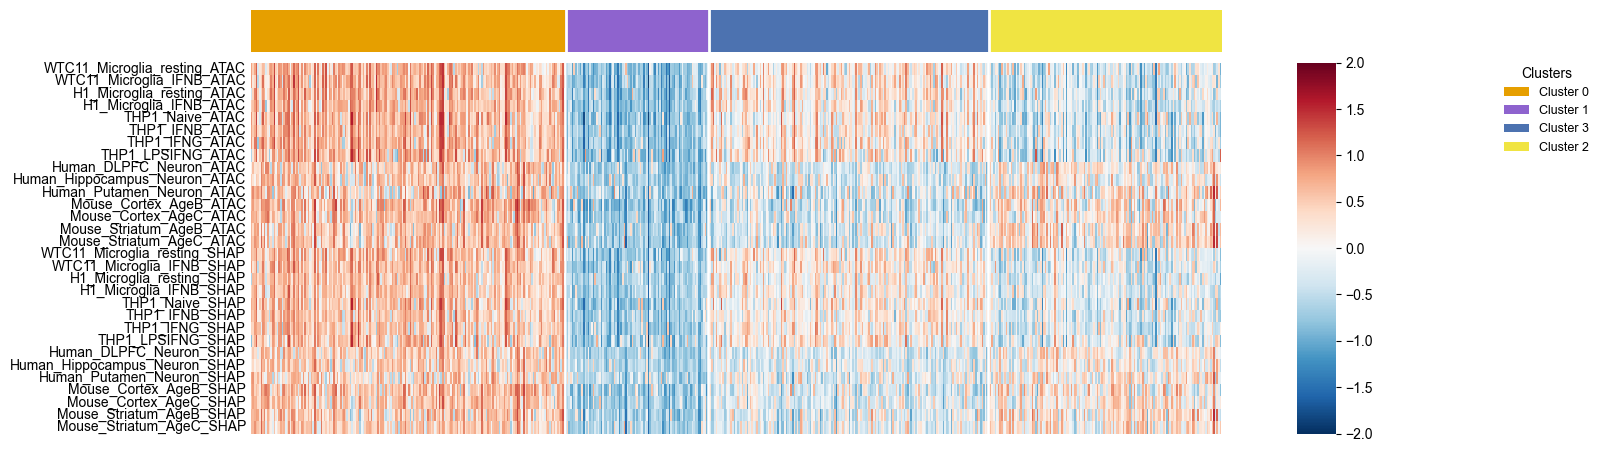

In [46]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib import gridspec

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ==========================
# 0. Plot style
# ==========================
mpl.rcParams.update({
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
    'font.family': 'Arial',
})

# ==========================
# 1. Select columns
# ==========================
select_columns_prediction = [
    'WTC11_resting_Prediction','WTC11_IFNB_Prediction',
    'H1_IFNB-model-best_Prediction','H1_resting-model_Prediction',
    'THP1_Naive-Calvin_Prediction','THP1_IFNB-Calvin_Prediction',
    'THP1_IFNG-Calvin_Prediction','THP1_LPSIFNG-Calvin_Prediction',
    'fullard_DLPFC-model-best_Prediction','fullard_hippocampus-model-best_Prediction',
    'fullard_putamen-model-best_Prediction',
    'Mouse_Cortex_AgeB-model_Prediction','Mouse_Cortex_AgeC-model_Prediction',
    'Mouse_Striatum_AgeB_Prediction','Mouse_Striatum_AgeC_Prediction',
    'HEK293_ATAC_high_depth0729_Prediction','HEK293T_ATAC_Prediction',
]

select_columns_shap = [
    'WTC11_resting-model-best_SHAP_SHAP','WTC11_IFNB-model-best_SHAP_SHAP',
    'H1_IFNB-model-best_SHAP_SHAP','H1_resting-model-best_SHAP_SHAP',
    'THP1_Naive-model-best_SHAP_SHAP','THP1_IFNB-model-best_SHAP_SHAP',
    'THP1_IFNG-model-best_SHAP_SHAP','THP1_LPSIFNG_Calvin_SHAP_SHAP',
    'fullard_DLPFC-model-best_SHAP_SHAP','fullard_hippocampus-model-best_SHAP_SHAP',
    'fullard_putamen-model-best_SHAP_SHAP',
    'Mouse_Cortex_AgeB-model-best_SHAP_SHAP','Mouse_Cortex_AgeC-model-best_SHAP_SHAP',
    'Mouse_Striatum_AgeB-model-best_SHAP_SHAP','Mouse_Striatum_AgeC-model-best_SHAP_SHAP',
    'HEK293_ATAC_high_depth0729-model-best_SHAP_SHAP','HEK293T_ATAC-model-best_SHAP_SHAP',
]

# ==========================
# 2. Prepare ATAC / SHAP matrices
# ==========================
columns_to_drop_atac = ['THP1_monocyte0729']
df_signed_neg_log_p_atac2 = df_signed_neg_log_p_atac.drop(columns=columns_to_drop_atac, axis=1)

columns_to_drop_shap = ['THP1_monocyte0729-model-best_SHAP']
df_signed_neg_log_p_shap2 = df_signed_neg_log_p_shap.drop(columns=columns_to_drop_shap, axis=1)

df_signed_neg_log_p_shap2.columns = [f"{c}_SHAP" for c in df_signed_neg_log_p_shap2.columns]
df_signed_neg_log_p_atac2.columns = [f"{c}_Prediction" for c in df_signed_neg_log_p_atac2.columns]

scaled_data = pd.concat(
    [df_signed_neg_log_p_atac2, df_signed_neg_log_p_shap2],
    axis=1
)[select_columns_prediction + select_columns_shap]

new_columns = [
    'WTC11_Microglia_resting_ATAC',
    'WTC11_Microglia_IFNB_ATAC',
    'H1_Microglia_resting_ATAC',
    'H1_Microglia_IFNB_ATAC',
    'THP1_Naive_ATAC',
    'THP1_IFNB_ATAC',
    'THP1_IFNG_ATAC',
    'THP1_LPSIFNG_ATAC',
    'Human_DLPFC_Neuron_ATAC',
    'Human_Hippocampus_Neuron_ATAC',
    'Human_Putamen_Neuron_ATAC',
    'Mouse_Cortex_AgeB_ATAC',
    'Mouse_Cortex_AgeC_ATAC',
    'Mouse_Striatum_AgeB_ATAC',
    'Mouse_Striatum_AgeC_ATAC',
    'HEK293_ATAC',
    'HEK293T_ATAC',
    'WTC11_Microglia_resting_SHAP',
    'WTC11_Microglia_IFNB_SHAP',
    'H1_Microglia_resting_SHAP',
    'H1_Microglia_IFNB_SHAP',
    'THP1_Naive_SHAP',
    'THP1_IFNB_SHAP',
    'THP1_IFNG_SHAP',
    'THP1_LPSIFNG_SHAP',
    'Human_DLPFC_Neuron_SHAP',
    'Human_Hippocampus_Neuron_SHAP',
    'Human_Putamen_Neuron_SHAP',
    'Mouse_Cortex_AgeB_SHAP',
    'Mouse_Cortex_AgeC_SHAP',
    'Mouse_Striatum_AgeB_SHAP',
    'Mouse_Striatum_AgeC_SHAP',
    'HEK293_SHAP',
    'HEK293T_SHAP',
]

scaled_data.columns = new_columns

# drop HEK293 / HEK293T
scaled_data = scaled_data.drop(
    ['HEK293_SHAP', 'HEK293T_SHAP', 'HEK293_ATAC', 'HEK293T_ATAC'],
    axis=1
)

# ==========================
# 3. KMeans clustering
# ==========================
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=43, n_init=20)
clusters = kmeans.fit_predict(scaled_data)
scaled_data['Cluster'] = clusters

silhouette_avg = silhouette_score(scaled_data.drop(columns='Cluster'), clusters)
print(f"Silhouette Score: {silhouette_avg:.3f}")

# ==========================
# 4. Manual cluster order
# ==========================
# 你要的是：原始图中从下往上 = 2,3,1,0
# 等价于原始图中从上往下 = 0,1,3,2
#
# 然后我们再把图转置（相当于向右转90度）
# 最终视觉上会变成：从左到右 = 2,3,1,0
#
# 如果你想转置后从左到右 = 0,1,3,2，
# 就把下面 manual_order_top_to_bottom 改成 [2,3,1,0]

manual_order_top_to_bottom = [0, 1, 3, 2]

order_map = {cluster_val: rank for rank, cluster_val in enumerate(manual_order_top_to_bottom)}
scaled_data['manual_order'] = scaled_data['Cluster'].map(order_map)

df_cluster = scaled_data.sort_values(
    by=['manual_order', 'Cluster'],
    ascending=[True, True]
).copy()

# 看一下排序是否真的生效
print("Top 20 cluster labels after sorting:")
print(df_cluster['Cluster'].head(20).tolist())
print("Bottom 20 cluster labels after sorting:")
print(df_cluster['Cluster'].tail(20).tolist())

# ==========================
# 5. Separate cluster annotation and matrix
# ==========================
cluster_series_sorted = df_cluster['Cluster'].copy()
df_cluster_for_plot = df_cluster.drop(columns=['Cluster', 'manual_order'], axis=1)

# 转置：相当于把原图向右转90度
plot_mat = df_cluster_for_plot.T

# cluster 颜色（对应每一列，因为转置后列是原来的 variant）
cluster_colors = {
    0: '#E69F00',  # orange
    1: '#8E63CE',  # purple
    2: '#F0E442',  # yellow
    3: '#4C72B0',  # blue
}
cluster_color_list = cluster_series_sorted.map(cluster_colors).tolist()

# 用整数编码做 annotation bar
cluster_code_map = {0: 0, 1: 1, 2: 2, 3: 3}
cluster_codes = np.array([cluster_code_map[c] for c in cluster_series_sorted])[None, :]

cluster_cmap = ListedColormap([
    cluster_colors[0],
    cluster_colors[1],
    cluster_colors[2],
    cluster_colors[3],
])

# ==========================
# 6. Plot
# ==========================
fig = plt.figure(figsize=(14, 5.5))
gs = gridspec.GridSpec(
    nrows=2,
    ncols=2,
    width_ratios=[40, 1.6],
    height_ratios=[0.55, 4.8],
    wspace=0.15,
    hspace=0.05
)

ax_bar = fig.add_subplot(gs[0, 0])
ax_heat = fig.add_subplot(gs[1, 0])
cax = fig.add_subplot(gs[1, 1])

# top cluster bar
ax_bar.imshow(
    cluster_codes,
    aspect='auto',
    cmap=cluster_cmap,
    interpolation='nearest'
)
ax_bar.set_xticks([])
ax_bar.set_yticks([])
for spine in ax_bar.spines.values():
    spine.set_visible(False)

# heatmap
sns.heatmap(
    plot_mat,
    ax=ax_heat,
    cmap='RdBu_r',
    vmin=-2,
    vmax=2,
    xticklabels=False,   # 变体太多通常不显示
    yticklabels=True,
    cbar=True,
    cbar_ax=cax,
    linewidths=0,
    rasterized=True
)

ax_heat.set_xlabel('')
ax_heat.set_ylabel('')
ax_heat.tick_params(axis='y', labelsize=10, length=0)
ax_heat.tick_params(axis='x', length=0)

# ==========================
# 7. Add vertical separators between cluster blocks
# ==========================
cluster_array = cluster_series_sorted.to_numpy()
boundaries = np.where(cluster_array[:-1] != cluster_array[1:])[0] + 1

for b in boundaries:
    ax_bar.axvline(b, color='white', lw=2)
    ax_heat.axvline(b, color='white', lw=1.8)

# ==========================
# 8. Legend
# ==========================
legend_handles = [
    Patch(facecolor=cluster_colors[k], edgecolor='none', label=f'Cluster {k}')
    for k in [0, 1, 3, 2]
]
ax_heat.legend(
    handles=legend_handles,
    title='Clusters',
    bbox_to_anchor=(1.28, 1.02),
    loc='upper left',
    frameon=False,
    fontsize=9,
    title_fontsize=10
)

# ==========================
# 9. Save
# ==========================
plt.savefig(
    'Heatmap_rotated_right90_clusterorder_2310.pdf',
    dpi=300,
    bbox_inches='tight',
    transparent=True
)
plt.show()

In [50]:
all_pos_majorminor_logfc.columns

Index(['fullard_putamen-model-best', 'fullard_DLPFC-model-best',
       'fullard_hippocampus-model-best', 'H1_IFNB-model-best',
       'H1_resting-model', 'HEK293_ATAC_high_depth0729', 'HEK293T_ATAC',
       'Mouse_Cortex_AgeB-model', 'Mouse_Cortex_AgeC-model',
       'Mouse_Striatum_AgeB', 'Mouse_Striatum_AgeC', 'THP1_IFNB-Calvin',
       'THP1_IFNG-Calvin', 'THP1_LPSIFNG-Calvin', 'THP1_monocyte0729',
       'THP1_Naive-Calvin', 'WTC11_IFNB', 'WTC11_resting'],
      dtype='object')

In [52]:

all_pos_diff_unique_norm = all_pos_majorminor_logfc
all_pos_diff_unique_norm = all_pos_diff_unique_norm[[
       'fullard_putamen-model-best', 'fullard_DLPFC-model-best','fullard_hippocampus-model-best',
       'Mouse_Cortex_AgeB-model', 'Mouse_Cortex_AgeC-model',
       'Mouse_Striatum_AgeB', 'Mouse_Striatum_AgeC', 
       'THP1_Naive-Calvin','THP1_IFNB-Calvin',
       'THP1_IFNG-Calvin', 'THP1_LPSIFNG-Calvin', 
       'WTC11_IFNB','WTC11_resting', 'H1_IFNB-model-best','H1_resting-model',]]
all_pos_diff_unique_norm.columns = [
'Human_Putamen_Neuron',
'Human_DLPFC_Neuron',
'Human_Hippocampus_Neuron',
'Mouse_Cortex_AgeB',
'Mouse_Cortex_AgeC',
'Mouse_Striatum_AgeB',
'Mouse_Striatum_AgeC',
'THP1_Macrophage_Naive',
'THP1_Macrophage_IFNB',
'THP1_Macrophage_IFNG',
'THP1_Macrophage_LPSIFNG',
'iPSC_Microglia_IFNB',
'iPSC_Microglia_Naive',
'hESC_Microglia_IFNB',
'hESC_Microglia_Naive',

]
all_pos_diff_unique_norm.to_csv('/media/zihengc/T7/THP1_machinelearning/prediction/allele_differences_genomic_mpra/majorminor_logFC.csv')

In [17]:
all_pos_diff_unique_norm = all_pos_diff_unique/all_pos_diff_unique.std()
all_pos_diff_unique_norm = all_pos_diff_unique_norm[['Mouse_Cortex_AgeB-model', 'Mouse_Cortex_AgeC-model',
       'Mouse_Striatum_AgeB', 'Mouse_Striatum_AgeC', 'THP1_Naive-Calvin','THP1_IFNB-Calvin',
       'THP1_IFNG-Calvin', 'THP1_LPSIFNG-Calvin', 'WTC11_IFNB','H1_resting-model', 'WTC11_resting' ]]
all_pos_diff_unique_norm.columns = ['Mouse_Cortex_AgeB',
'Mouse_Cortex_AgeC',
'Mouse_Striatum_AgeB',
'Mouse_Striatum_AgeC',
'THP1_Macrophage_Naive',
'THP1_Macrophage_IFNB',
'THP1_Macrophage_IFNG',
'THP1_Macrophage_LPSIFNG',
'iPSC_Microglia_IFNB',
'hESC_Microglia_Naive',
'iPSC_Microglia_Naive',
]
all_pos_diff_unique_norm.to_csv('/media/zihengc/T7/THP1_machinelearning/prediction/allele_differences_genomic_mpra/normalized_majorminor_alleledifference.csv')

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from adjustText import adjust_text

def plot_scatter_with_outliers(df_cluster, x_cell, y_cell, x_label, y_label, title,
                               difference_threshold = 2, save_file=None,outlier_file=None ):
    """
    Plot scatter with regression line and highlight outliers.
    
    Parameters:
    - df_cluster: DataFrame containing the data.
    - x_cell: Column name for the x-axis.
    - y_cell: Column name for the y-axis.
    - x_label: Label for the x-axis.
    - y_label: Label for the y-axis.
    - title: Title for the plot.
    - difference_threshold: Threshold in standard deviations to label points as outliers.
    - save_file: Path to save the plot as an image (optional).
    """
    # Define the x and y variables
    x = df_cluster[x_cell].values.reshape(-1, 1)
    y = df_cluster[y_cell].values

    # Fit a linear regression model
    model = LinearRegression()
    model.fit(x, y)

    # Predict y values based on the fitted model
    y_pred = model.predict(x)

    # ----------- Calculate R^2 -----------
    # Option 1: Using built-in model.score
    r2_score_builtin = model.score(x, y)
    
    # Option 2: Using the r2_score function
    r2_score_manual = r2_score(y, y_pred)

    print(f"R^2 (model.score): {r2_score_builtin:.4f}")
    print(f"R^2 (r2_score):    {r2_score_manual:.4f}")
    # -------------------------------------

    # Calculate residuals
    residuals = y - y_pred

    # Define outliers as points where residuals > threshold * std
    threshold = difference_threshold * np.std(residuals)
    outliers = np.abs(residuals) > threshold

    # Add residuals and outlier information to df_cluster
    df_cluster['Residual'] = residuals
    df_cluster['Outlier'] = outliers

    # Color coding
    df_cluster['Color'] = np.where(df_cluster['Outlier'], 'green', 'lightgrey')  # Green for outliers, grey for others

    # Plot
    plt.figure(figsize=(6, 6), dpi=300)
    plt.grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.3)

    # Scatter plot
    plt.scatter(
        df_cluster[x_cell],
        df_cluster[y_cell],
        c=df_cluster['Color'],
        alpha=0.7,
        s=10,
        edgecolor='none',
    )

    # Plot the regression line
    plt.plot(x, y_pred, color='blue', linewidth=2, label='Regression Line', alpha=0.3)

    # Highlight outliers (green points)
    green_points = df_cluster[df_cluster['Outlier']]
    green_points.to_csv(outlier_file)
    plt.scatter(
        green_points[x_cell],
        green_points[y_cell],
        color='green',
        label='Regression Outliers',
        s=10
    )

    # Add labels for outliers
    texts = []
    for idx, row in green_points.iterrows():
        texts.append(
            plt.text(
                row[x_cell],
                row[y_cell] + 0.2,
                row['rsid_protein_coding_gene'],
                fontsize=5,
                color='black',
                ha='center',
                va='bottom'
            )
        )

    # Adjust text to avoid overlap
    adjust_text(
        texts,
        force_text=(0.0, 0.1),
        force_points=(0.2, 0.2)
    )

    # Labels and title
    plt.xlabel(x_label, fontsize=10)
    plt.ylabel(y_label, fontsize=10)
    plt.title(title, fontsize=12, weight='bold')

    # Legend
    plt.legend(loc='upper left', fontsize=8)

    # Tight layout
    plt.tight_layout()

    # Save the plot if desired
    if save_file:
        plt.savefig(save_file, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_file}")

    # Show plot
    plt.show()


Plot saved to scatter_plot_LPSIFNGvsNaive.pdf


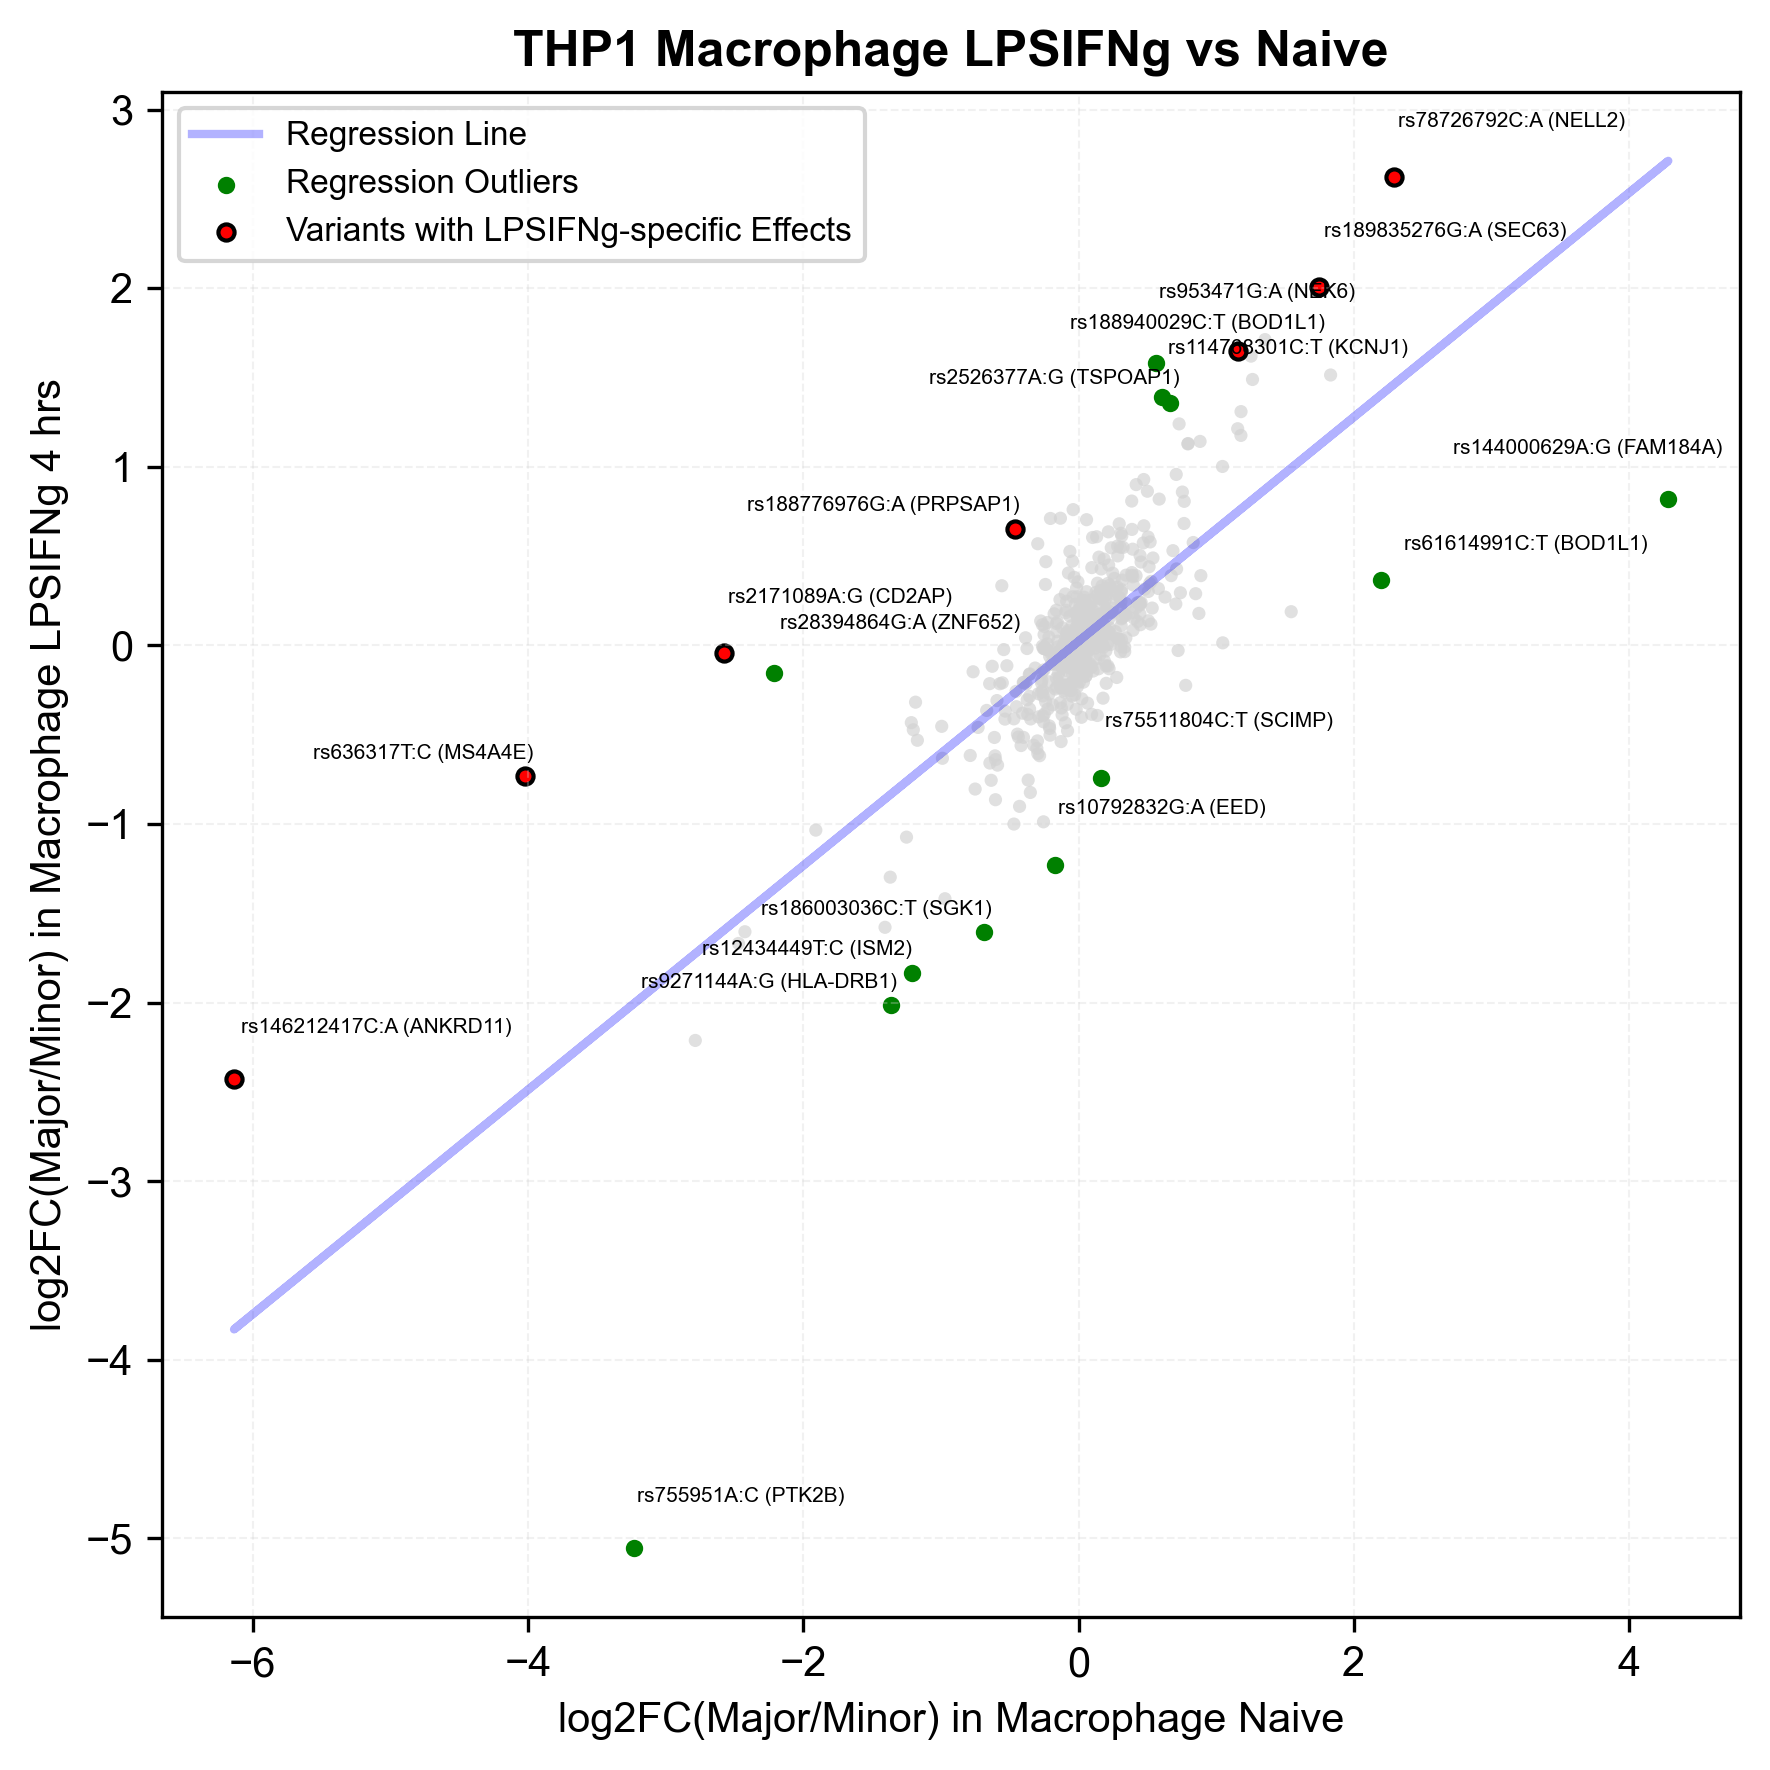

In [54]:
import pandas as pd
parsed_columns=pd.read_csv("20241202_model_type_sample_sheet.csv")
df_cluster = pd.read_csv( ('/media/zihengc/T7/THP1_machinelearning/prediction/allele_differences_genomic_mpra/majorminor_logFC.csv'),index_col=0)

df_diff = pd.read_csv('/media/zihengc/T7/THP1_machinelearning/prediction/allele_differences_genomic_mpra/THP1_LPSIFNGvsNaive_20240826_MPRA_500bp_SNPandControl_500bpbarcodes_one.csv',header=None )
df_diff = df_diff.groupby(df_diff.index//2).mean()
df_cluster['THP1_Macrophage_LPSIFNGvsNaive'] = np.array(df_diff[0][0:855])-np.array(df_diff[0][855:])


df_haploreg = pd.read_csv('indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_20250103.csv',index_col=0)
df_haploreg['rsid_protein_coding_gene'] = df_haploreg['rsID']+df_haploreg['Major']+":"+df_haploreg['Minor']+' (' +df_haploreg['closest_protein_coding_gene_TSS']+')'
df_cluster = pd.merge(df_cluster,df_haploreg[['rsid_protein_coding_gene','rsID']],left_index=True,right_index=True).drop_duplicates('rsID')
df_diff_sig_index = df_cluster[abs(df_cluster['THP1_Macrophage_LPSIFNGvsNaive'])>=0.05].index
data = df_cluster[parsed_columns['OriginalColumn'].tolist()]
data = data.reset_index()
data = data.rename(columns={'index': 'snp_id'}) 

x_cell='THP1_Macrophage_Naive'
y_cell='THP1_Macrophage_LPSIFNG'
x_label='log2FC(Major/Minor) in Macrophage Naive'
y_label='log2FC(Major/Minor) in Macrophage LPSIFNg 4 hrs'
title='THP1 Macrophage LPSIFNg vs Naive'
difference_threshold = 2.5
save_file='scatter_plot_LPSIFNGvsNaive.pdf'  # Optional: Provide a path to save the plot

# Define the x and y variables
x = df_cluster[x_cell].values.reshape(-1, 1)
y = df_cluster[y_cell].values

# Fit a linear regression model
model = LinearRegression()
model.fit(x, y)

# Predict y values based on the fitted model
y_pred = model.predict(x)

# Calculate residuals
residuals = y - y_pred

# Define outliers as points where residuals > 2.5 standard deviations
threshold = difference_threshold * np.std(residuals)
outliers = np.abs(residuals) > threshold

# Add residuals and outlier information to df_cluster
df_cluster['Residual'] = residuals
df_cluster['Outlier'] = outliers

# Update to only consider grey and green dots (ignoring red dots/significance)
df_cluster['Color'] = np.where(df_cluster['Outlier'], 'green', 'lightgrey')  # Green for outliers, grey for others

# Plot the scatter plot with only grey and green dots
plt.figure(figsize=(6, 6), dpi=300)

# Add gridlines for better readability
plt.grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.3)

# Scatter plot with custom colors
plt.scatter(
    df_cluster[x_cell],
    df_cluster[y_cell],
    c=df_cluster['Color'],
    alpha=0.7,
    s=10,
    edgecolor='none',
)



# Plot the regression line
plt.plot(x, y_pred, color='blue', linewidth=2, label='Regression Line', alpha=0.3)

# Highlight green dots and collect them for labeling
green_points = df_cluster[df_cluster['Outlier']]

plt.scatter(
    green_points[x_cell],
    green_points[y_cell],
    color='green',
    label='Regression Outliers',
    s=10
)

red_points = green_points[green_points.index.isin(df_diff_sig_index)]
plt.scatter(
    red_points[x_cell],
    red_points[y_cell],
    color='red',
    label='Variants with LPSIFNg-specific Effects',
    edgecolor='black',
    s=15
)
# Add labels for green dots using 'rsid_gene'
texts = []
for idx, row in green_points.iterrows():
    texts.append(
        plt.text(
            row[x_cell],
            row[y_cell] + 0.2,  # Offset slightly above the dot
            row['rsid_protein_coding_gene'],
            fontsize=5,
            color='black',
            ha='center',
            va='bottom'
        )
    )

# Adjust text positions to avoid overlap (no arrows)
adjust_text(
    texts,
    force_text=(0.0, 0.1),   # Push texts farther from each other (x and y forces)
    force_points=(0.2, 0.2)  # Push texts farther from points (x and y forces)
)

# Add labels and title
plt.xlabel(x_label, fontsize=10)
plt.ylabel(y_label, fontsize=10)
plt.title(title, fontsize=12, weight='bold')

# Add legend
plt.legend(loc='upper left', fontsize=8)

# Reduce excess whitespace
plt.tight_layout()

# Save the plot if a file name is provided
if save_file:
    plt.savefig(save_file, dpi=300, bbox_inches='tight')
    print(f"Plot saved to {save_file}")

# Display the plot
plt.show()


R^2 (model.score): 0.5455
R^2 (r2_score):    0.5455


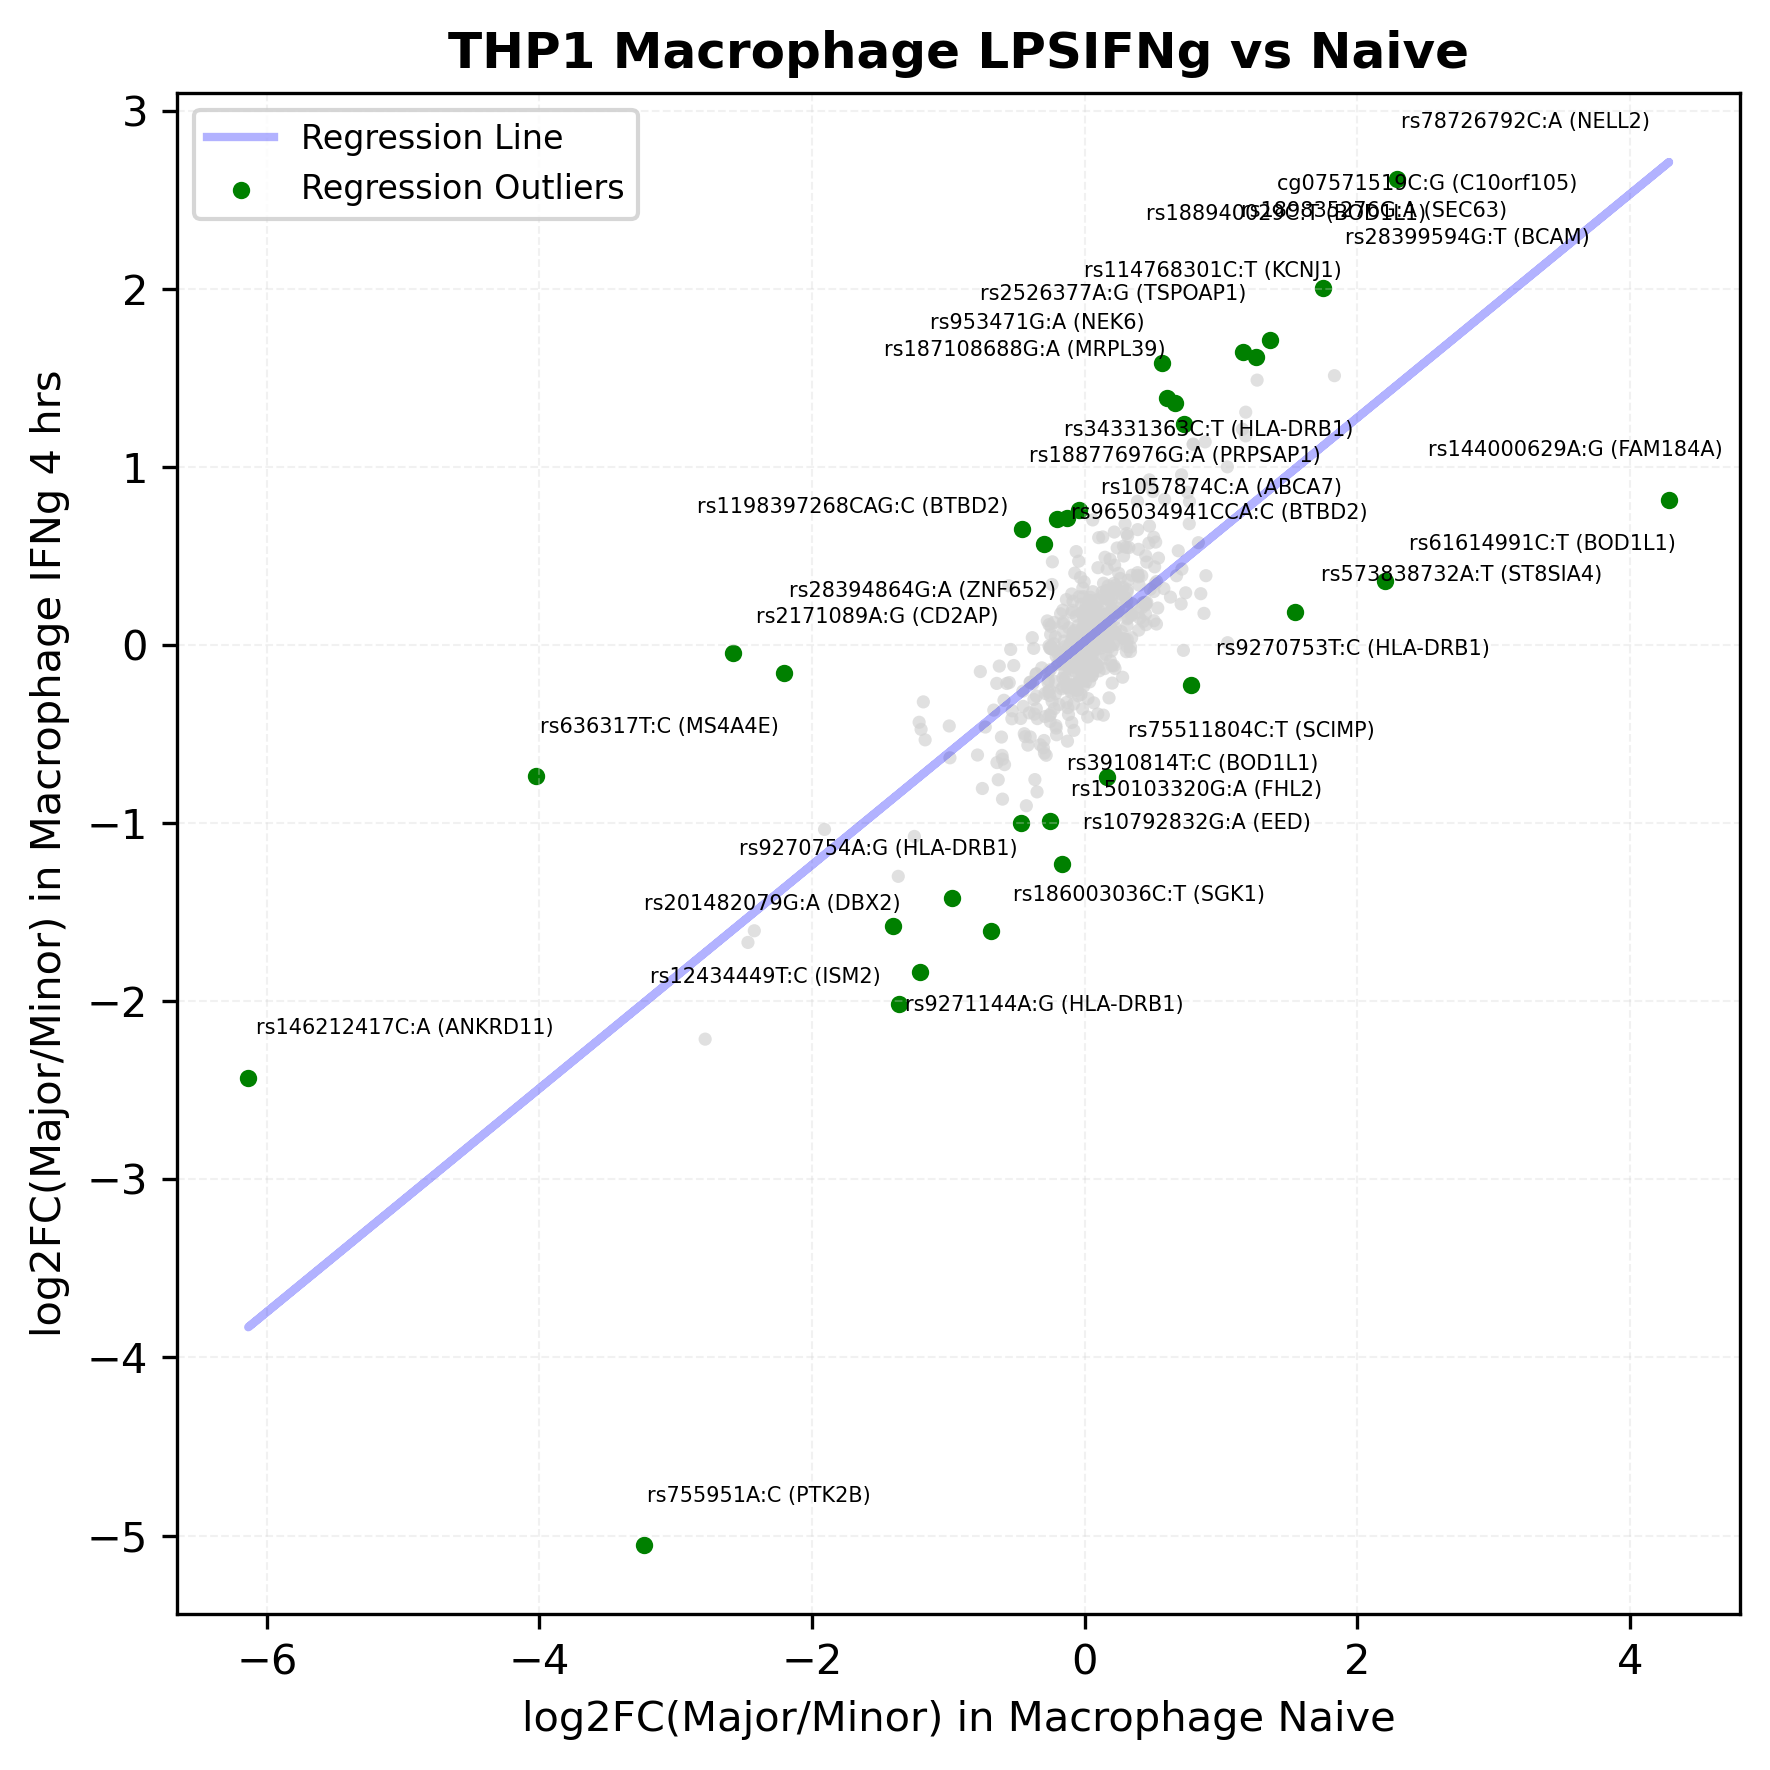

In [20]:
plot_scatter_with_outliers(
    df_cluster=df_cluster,
    x_cell='THP1_Macrophage_Naive',
    y_cell='THP1_Macrophage_LPSIFNG',
    x_label='log2FC(Major/Minor) in Macrophage Naive',
    y_label='log2FC(Major/Minor) in Macrophage IFNg 4 hrs',
    title='THP1 Macrophage LPSIFNg vs Naive',
    difference_threshold = 2,
    #save_file='scatter_plot_IFNGvsNaive.pdf',  # Optional: Provide a path to save the plot
    outlier_file = '/media/zihengc/T7/THP1_machinelearning/prediction/allele_differences_genomic_mpra/LPSIFNG_VS_Naive_logFC_outlier.csv'
)

R^2 (model.score): 0.5609
R^2 (r2_score):    0.5609
Plot saved to scatter_plot_IFNGvsNaive.pdf


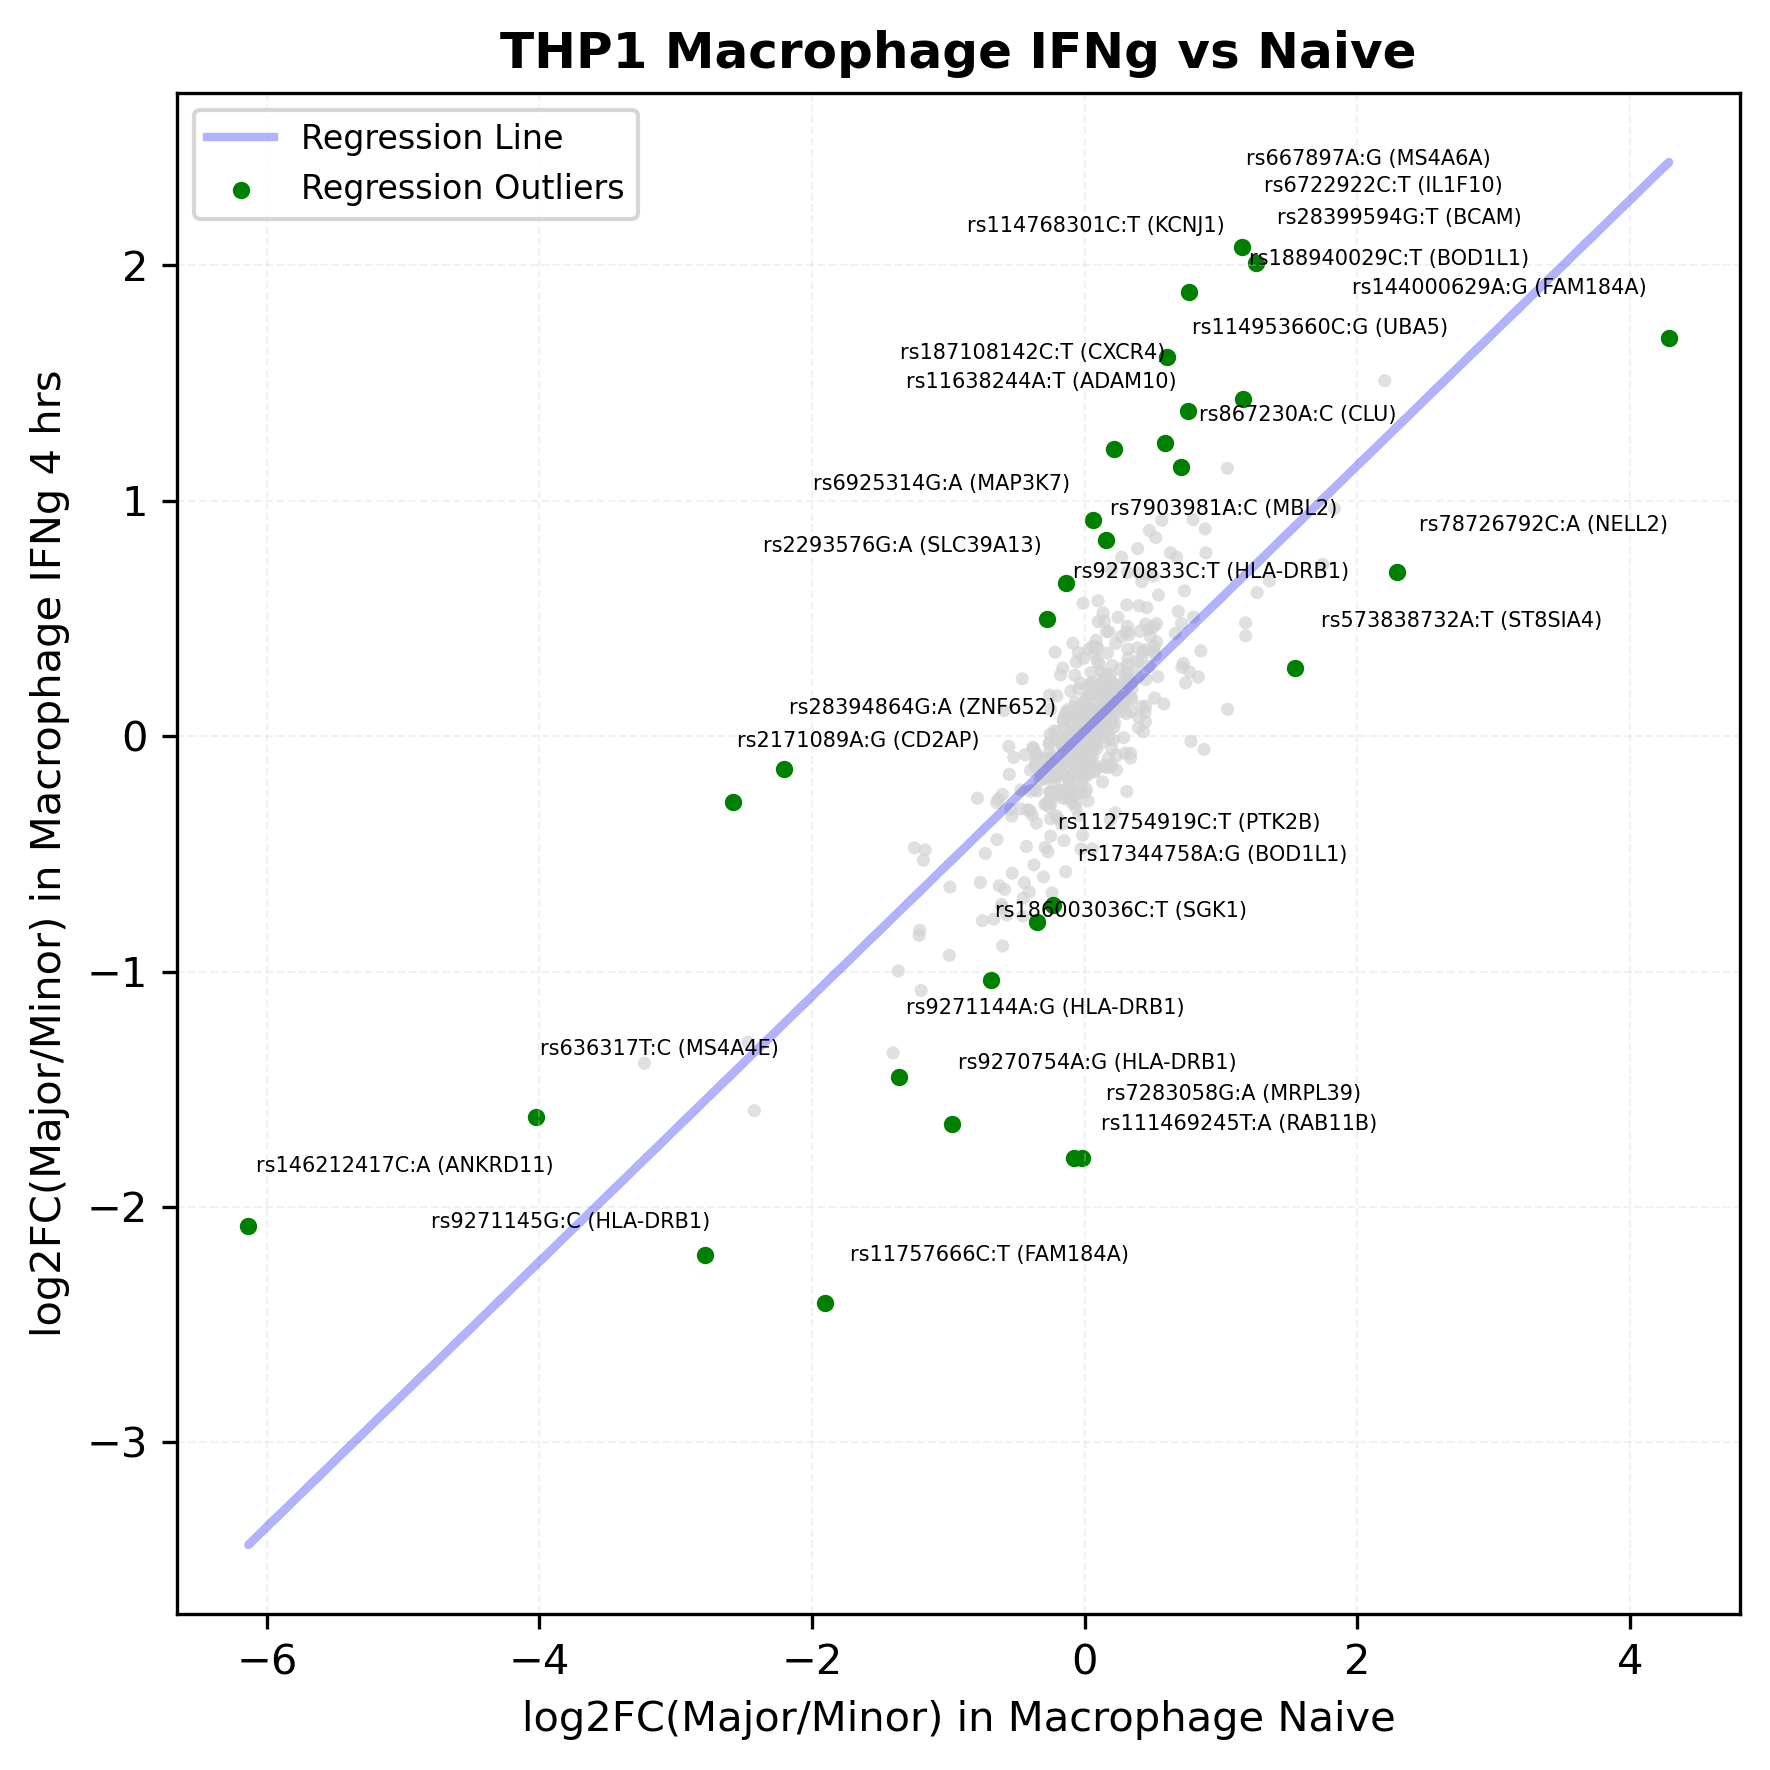

In [21]:
plot_scatter_with_outliers(
    df_cluster=df_cluster,
    x_cell='THP1_Macrophage_Naive',
    y_cell='THP1_Macrophage_IFNG',
    x_label='log2FC(Major/Minor) in Macrophage Naive',
    y_label='log2FC(Major/Minor) in Macrophage IFNg 4 hrs',
    title='THP1 Macrophage IFNg vs Naive',
    difference_threshold = 2,
    save_file='scatter_plot_IFNGvsNaive.pdf',  # Optional: Provide a path to save the plot
    outlier_file = '/media/zihengc/T7/THP1_machinelearning/prediction/allele_differences_genomic_mpra/IFNG_VS_Naive_logFC_outlier.csv'
)

R^2 (model.score): 0.6613
R^2 (r2_score):    0.6613
Plot saved to scatter_plot_IFNBvsNaive.pdf


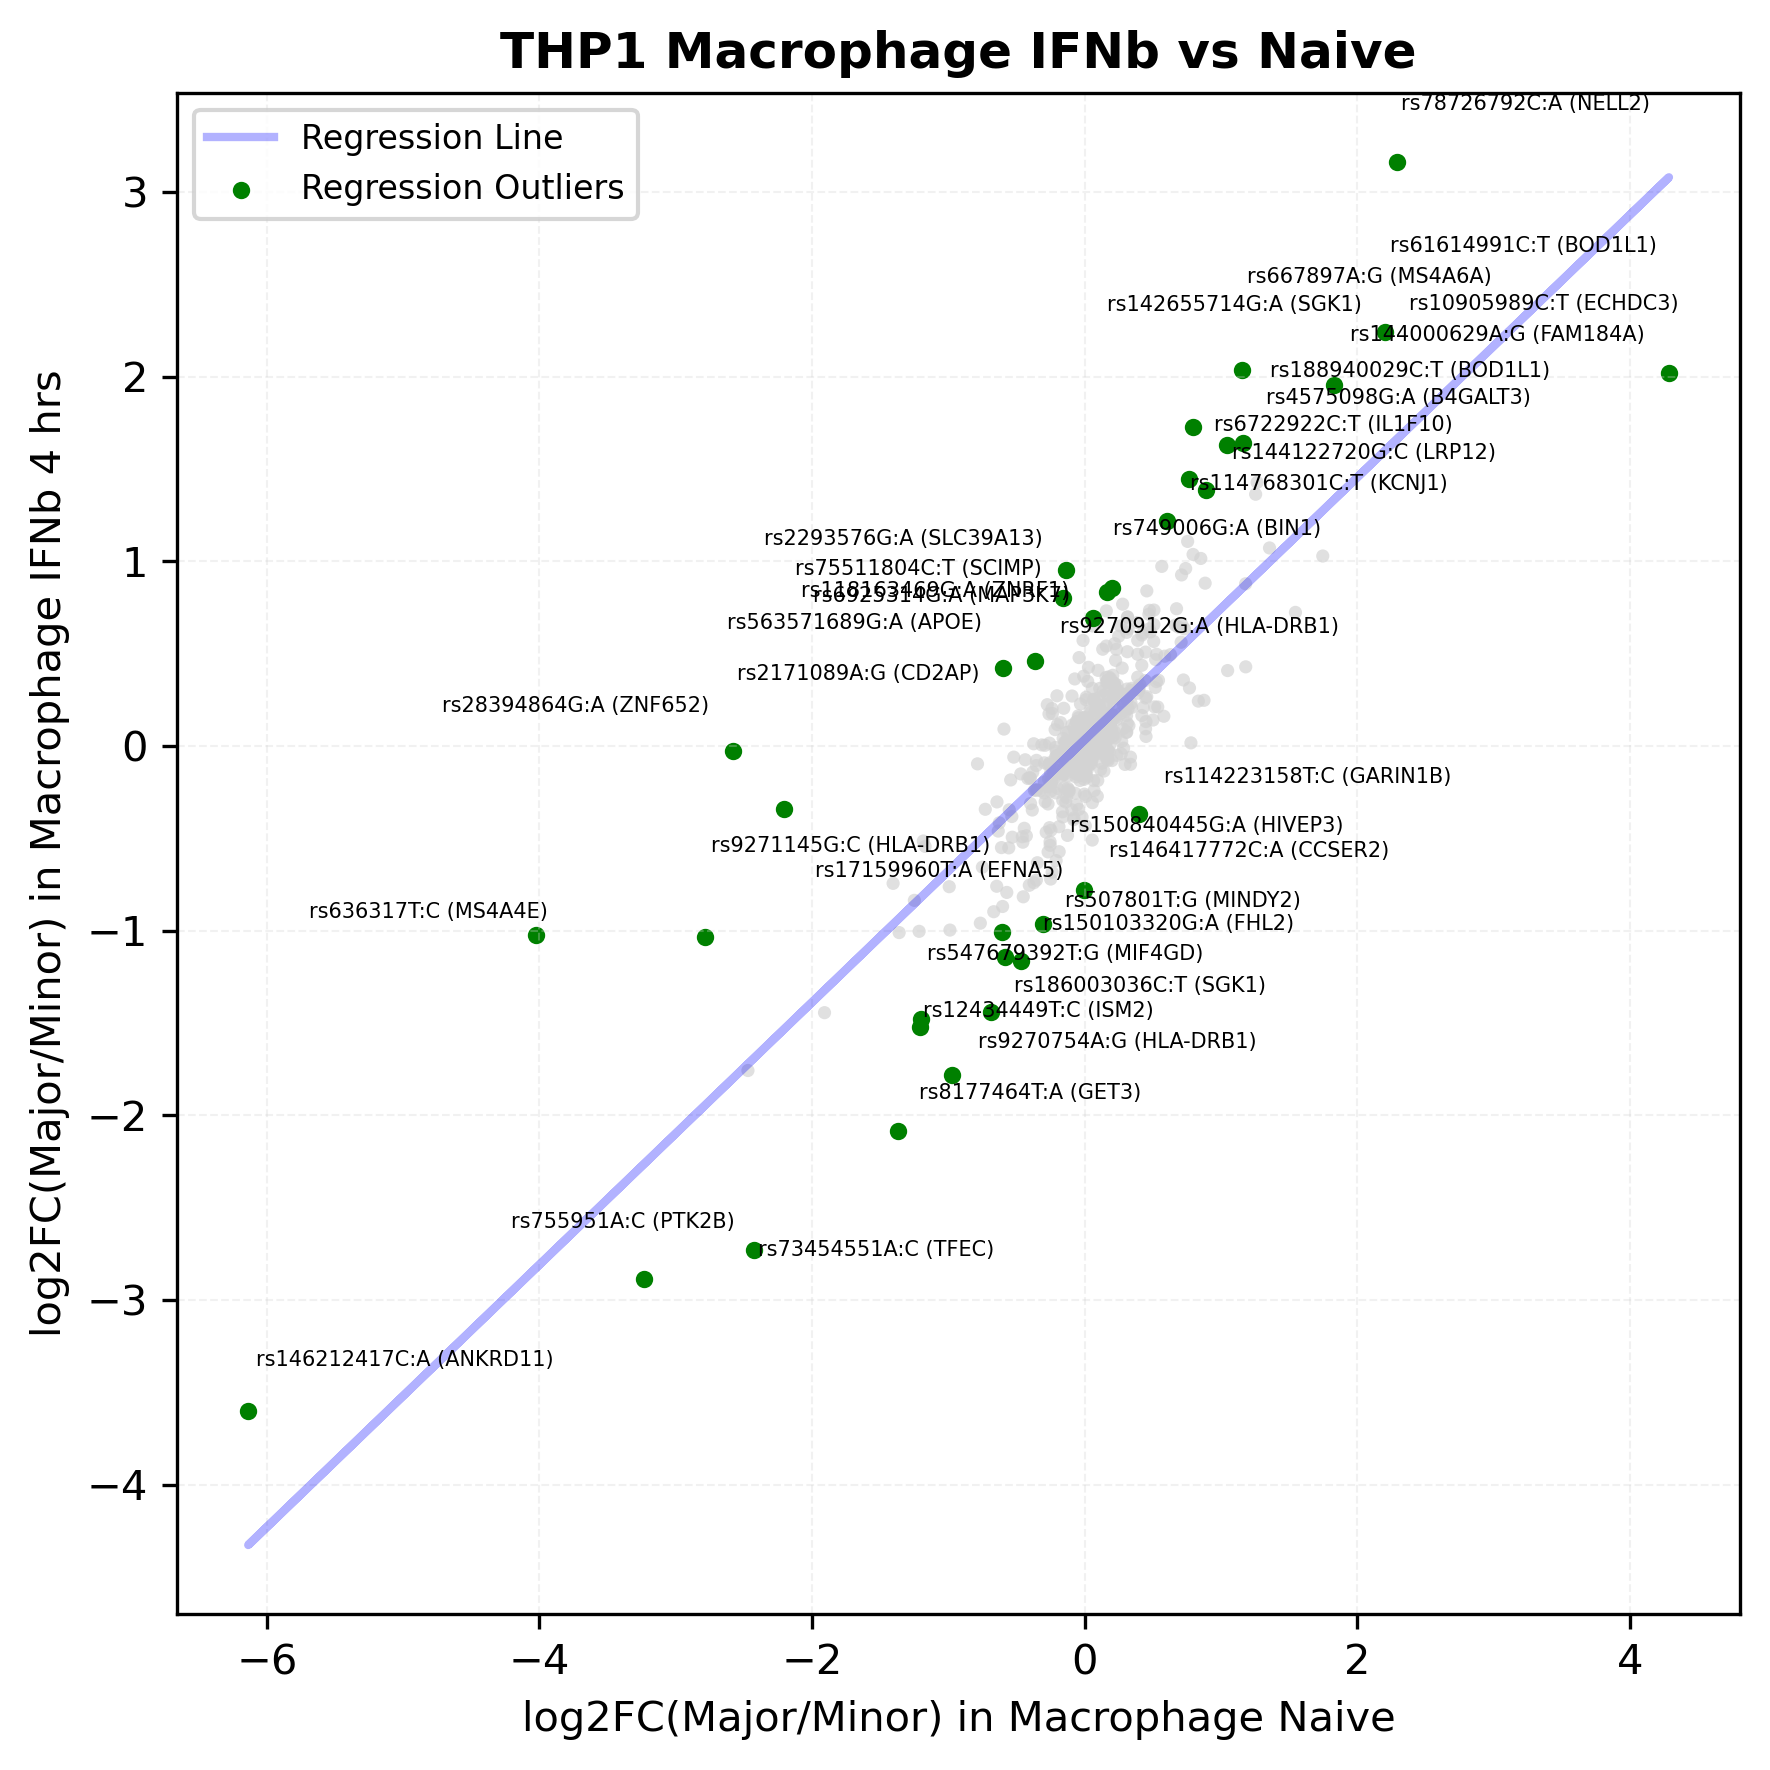

In [22]:
plot_scatter_with_outliers(
    df_cluster=df_cluster,
    x_cell='THP1_Macrophage_Naive',
    y_cell='THP1_Macrophage_IFNB',
    x_label='log2FC(Major/Minor) in Macrophage Naive',
    y_label='log2FC(Major/Minor) in Macrophage IFNb 4 hrs',
    title='THP1 Macrophage IFNb vs Naive',
    difference_threshold = 2,
    save_file='scatter_plot_IFNBvsNaive.pdf',  # Optional: Provide a path to save the plot
    outlier_file = '/media/zihengc/T7/THP1_machinelearning/prediction/allele_differences_genomic_mpra/IFNB_VS_Naive_logFC_outlier.csv'
)

R^2 (model.score): 0.2293
R^2 (r2_score):    0.2293
Plot saved to scatter_plot_StriatumvsCortex.pdf


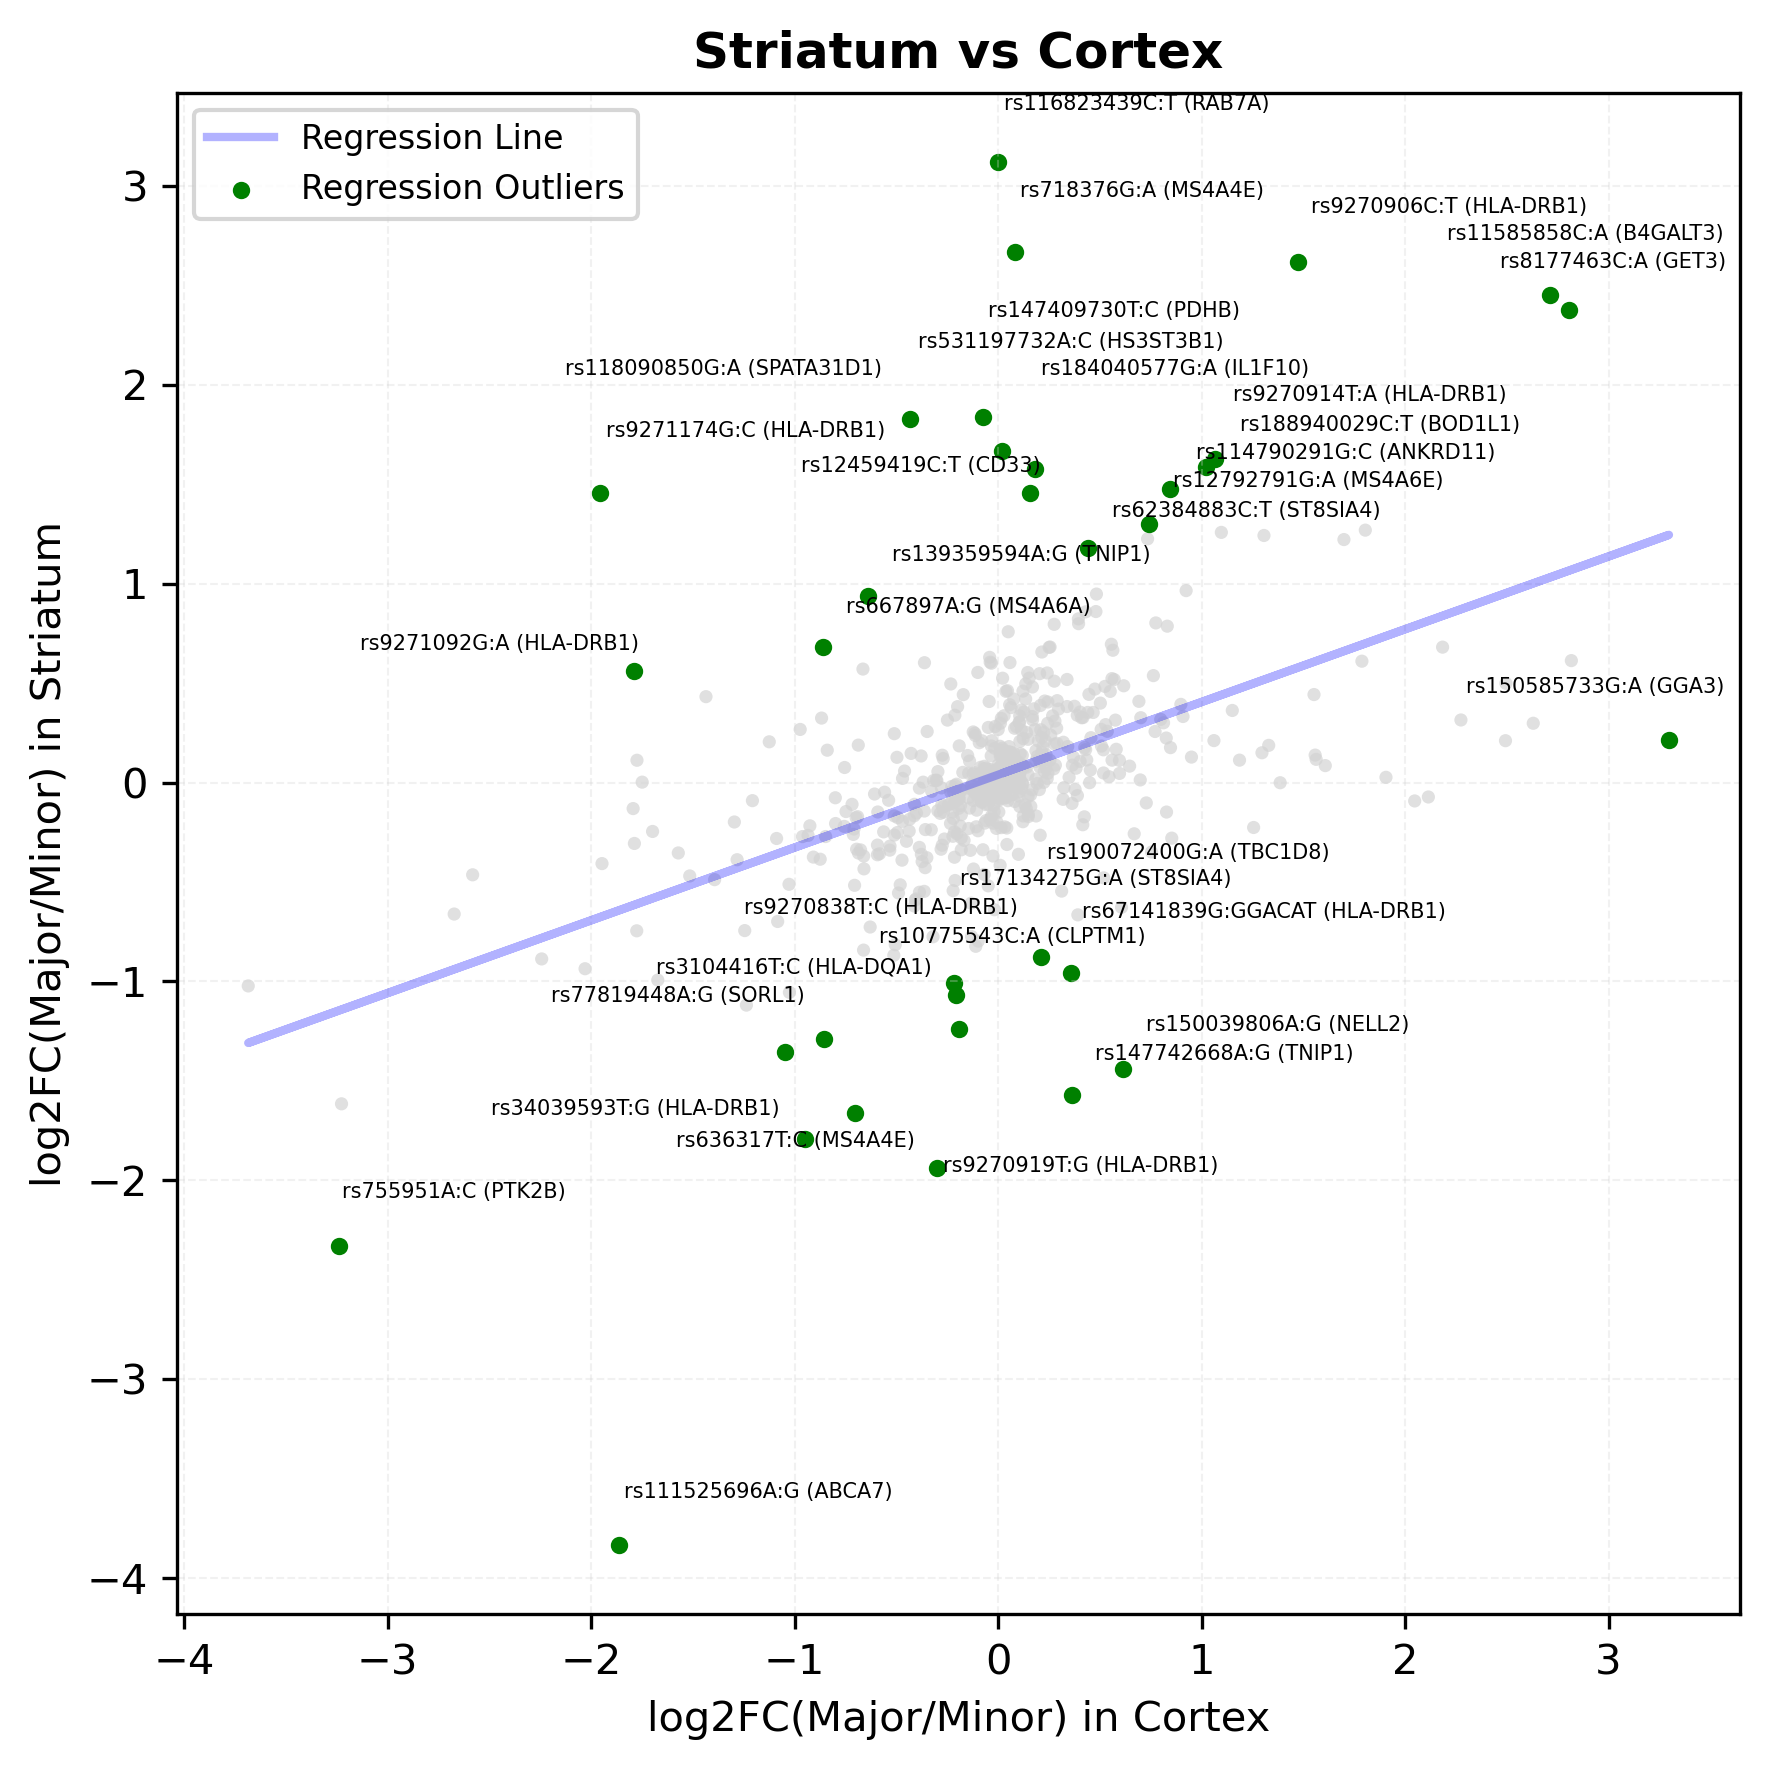

In [23]:
df_cluster_brain = pd.DataFrame()
df_cluster_brain['Mouse_Cortex'] = (df_cluster['Mouse_Cortex_AgeB'] + df_cluster['Mouse_Cortex_AgeC'])/2
df_cluster_brain['Mouse_Striatum'] = (df_cluster['Mouse_Striatum_AgeB'] + df_cluster['Mouse_Striatum_AgeC'])/2
df_cluster_brain['rsid_protein_coding_gene'] = df_cluster['rsid_protein_coding_gene']
plot_scatter_with_outliers(
    df_cluster=df_cluster_brain,
    x_cell='Mouse_Cortex',
    y_cell='Mouse_Striatum',
    x_label='log2FC(Major/Minor) in Cortex',
    y_label='log2FC(Major/Minor) in Striatum',
    title='Striatum vs Cortex',
    difference_threshold = 2,
    save_file='scatter_plot_StriatumvsCortex.pdf',  # Optional: Provide a path to save the plot
    outlier_file = '/media/zihengc/T7/THP1_machinelearning/prediction/allele_differences_genomic_mpra/Striatum_VS_Cortex_logFC_outlier.csv'
)

In [57]:
df_cluster.columns

Index(['Human_Putamen_Neuron', 'Human_DLPFC_Neuron',
       'Human_Hippocampus_Neuron', 'Mouse_Cortex_AgeB', 'Mouse_Cortex_AgeC',
       'Mouse_Striatum_AgeB', 'Mouse_Striatum_AgeC', 'THP1_Macrophage_Naive',
       'THP1_Macrophage_IFNB', 'THP1_Macrophage_IFNG',
       'THP1_Macrophage_LPSIFNG', 'iPSC_Microglia_IFNB',
       'iPSC_Microglia_Naive', 'hESC_Microglia_IFNB', 'hESC_Microglia_Naive',
       'rsid_protein_coding_gene', 'rsID'],
      dtype='object')

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


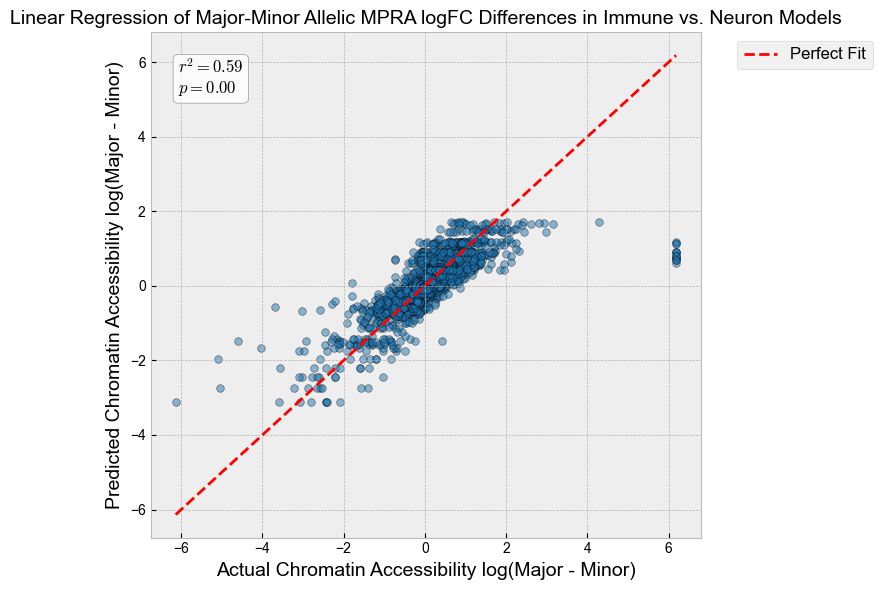

Overall R-squared: 0.5942


In [65]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests

mpl.rcParams.update({
    'pdf.fonttype': 42,      # embed TrueType fonts → Illustrator-editable
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
    'font.family': 'Arial',
})

# Step 1: Read input files
parsed_columns = pd.read_csv("20241202_model_type_sample_sheet.csv")
df_cluster = pd.read_csv(
    '/media/zihengc/T7/THP1_machinelearning/prediction/allele_differences_genomic_mpra/majorminor_logFC.csv',
    index_col=0
).drop(['Mouse_Cortex_AgeB', 'Mouse_Cortex_AgeC',
       'Mouse_Striatum_AgeB', 'Mouse_Striatum_AgeC'],axis=1)
df_haploreg = pd.read_csv(
    'indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_20250103.csv',
    index_col=0
)

df_haploreg['rsid_protein_coding_gene'] = (
    df_haploreg['rsID']
    + df_haploreg['Major']
    + ":"
    + df_haploreg['Minor']
    + ' ('
    + df_haploreg['closest_protein_coding_gene_TSS']
    + ')'
)

# Merge annotation
df_cluster = pd.merge(
    df_cluster,
    df_haploreg[['rsid_protein_coding_gene', 'rsID']],
    left_index=True,
    right_index=True
).drop_duplicates('rsID')

# Keep only columns in sample sheet
data = df_cluster[parsed_columns['OriginalColumn'].tolist()]
data = data.reset_index().rename(columns={'index': 'snp_id'})

# Step 2: Melt to long format
long_data = pd.melt(
    data,
    id_vars=['snp_id'],
    var_name='OriginalColumn',
    value_name='Major_Minor_logFC'
)

# Step 3: Merge sample metadata
long_data = long_data.merge(parsed_columns, on='OriginalColumn')

# Match first script: keep only Human subtype
long_data = long_data[long_data['SubType'] == 'Human'].copy()

# Match first script: define CellType order explicitly
long_data['CellType'] = pd.Categorical(
    long_data['CellType'],
    categories=['Immune', 'Neuron']
)

# Step 4: Fit per-SNP regression using same formula as first script
predictions = []
results = []

for snp_id, snp_data in long_data.groupby('snp_id'):
    snp_data = snp_data.copy()
    model = smf.ols('Major_Minor_logFC ~ C(CellType)', data=snp_data).fit()
    snp_data['Predicted'] = model.predict(snp_data)
    predictions.append(snp_data)
    results.append({
        'SNP_ID': snp_id,
        'Coefficients': model.params,
        'PValues': model.pvalues,
    })

predicted_data = pd.concat(predictions)

####################################################
# Step 5: Plot actual vs predicted
plt.style.use('bmh')

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    predicted_data['Major_Minor_logFC'],
    predicted_data['Predicted'],
    s=30,
    alpha=0.5,
    edgecolors='k',
    facecolors='#1f77b4',
    label=''
)

min_val = predicted_data['Major_Minor_logFC'].min()
max_val = predicted_data['Major_Minor_logFC'].max()

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='red',
    linestyle='--',
    lw=2,
    label='Perfect Fit'
)

r, p = pearsonr(predicted_data['Major_Minor_logFC'], predicted_data['Predicted'])
r2_value = r ** 2

ax.text(
    0.05, 0.95,
    f'$r^2 = {r2_value:.2f}$\n$p = {p:.2f}$',
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.8)
)

ax.set_xlabel('Actual Chromatin Accessibility log(Major - Minor)', fontsize=14)
ax.set_ylabel('Predicted Chromatin Accessibility log(Major - Minor)', fontsize=14)
ax.set_title(
    'Linear Regression of Major-Minor Allelic MPRA logFC Differences in Immune vs. Neuron Models',
    fontsize=14
)

ax.legend(fontsize=12, loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.savefig('major_minor_logFC_regression.pdf', dpi=300, bbox_inches='tight')
plt.show()

####################################################
# Step 6: Overall R-squared
overall_r2 = r2_score(predicted_data['Major_Minor_logFC'], predicted_data['Predicted'])
print(f"Overall R-squared: {overall_r2:.4f}")

####################################################
# Step 7: Extract CellType effect p-values and coefficients
celltype_pvalues = []
snp_ids = []
coefficients = []

for result in results:
    pvalue = result['PValues'].get('C(CellType)[T.Neuron]', None)
    coef = result['Coefficients'].get('C(CellType)[T.Neuron]', None)

    if pvalue is not None:
        celltype_pvalues.append(pvalue)
        snp_ids.append(result['SNP_ID'])
        coefficients.append(coef)

adjusted_pvalues = multipletests(celltype_pvalues, method='fdr_bh')[1]

results_df = pd.DataFrame({
    'SNP_ID': snp_ids,
    'CellType_PValue': celltype_pvalues,
    'Adj_PValue': adjusted_pvalues,
    'Coefficient': coefficients
})

# Same thresholding logic as your second script
results_df['Significant'] = (
    (results_df['Adj_PValue'] <= 0.05) &
    (results_df['Coefficient'].abs() >= 0.5)
)

results_df['neg_log10_Adj_PValue'] = -np.log10(results_df['Adj_PValue'])
results_df = results_df.set_index('SNP_ID')

results_df = pd.merge(
    results_df,
    df_haploreg[['rsid_protein_coding_gene']],
    left_index=True,
    right_index=True
)

significant_snps = results_df[results_df['Significant']].copy()

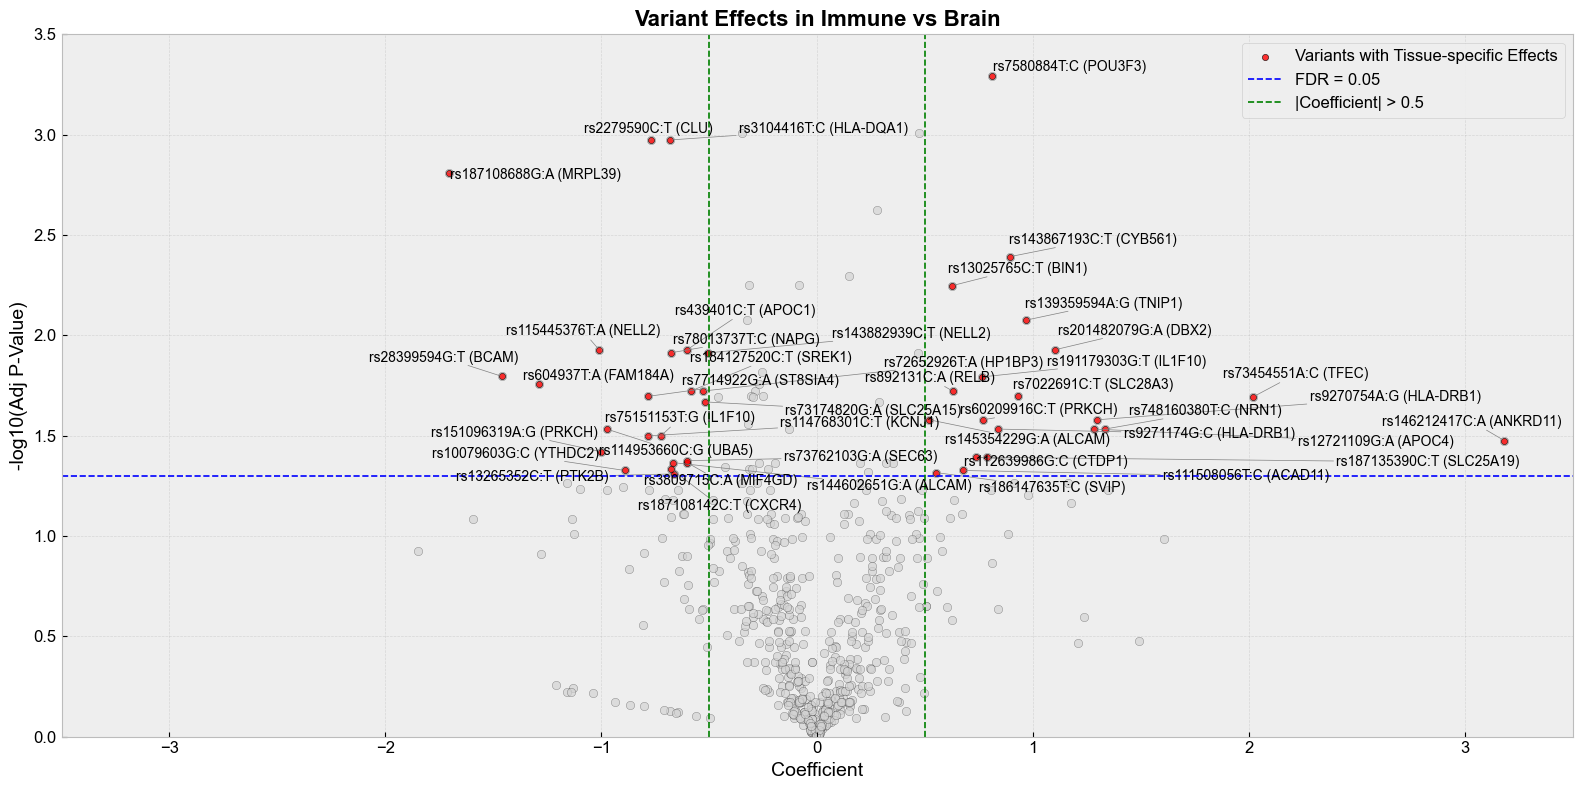

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text

df = results_df

# Create a figure
plt.figure(figsize=(16, 8))

# Highlight significant points
significant = df[(df["Adj_PValue"] <= 0.05) & (abs(df["Coefficient"]) >= 0.5)]

# Scatter plot for all SNPs (light grey)
plt.scatter(
    df["Coefficient"],
    df["neg_log10_Adj_PValue"],
    color="lightgrey",
    alpha=0.7,
    edgecolor="black",
    linewidth=0.2,
    label="",
)

# Scatter plot for significant SNPs (red)
plt.scatter(
    significant["Coefficient"],
    significant["neg_log10_Adj_PValue"],
    color="red",
    alpha=0.8,
    edgecolor="black",
    linewidth=0.5,
    label="Variants with Tissue-specific Effects",
    s= 20
)

# Only proceed if the column 'rsid_protein_coding_gene' is present
if "rsid_protein_coding_gene" in df.columns:
    # Collect text objects for significant SNPs in a list for adjustText
    texts = []
    for _, row in significant.iterrows():
        # Create a text label at the point's coordinates
        txt = plt.text(
            row["Coefficient"],
            row["neg_log10_Adj_PValue"],
            row["rsid_protein_coding_gene"],
            fontsize=10,
            ha="left",  # position text to the left (could be "right", etc.)
            color="black",
        )
        texts.append(txt)

    # Use adjust_text to automatically separate labels (avoid overlap)
    adjust_text(
        texts,
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.5),  # optional arrows
    )
else:
    print("The column 'rsid_protein_coding_gene' is not found in the dataset.")

# Add dashed lines for thresholds
plt.axhline(
    -np.log10(0.05),
    color="blue",
    linestyle="--",
    linewidth=1.2,
    label="FDR = 0.05"
)
plt.axvline(
    -0.5,
    color="green",
    linestyle="--",
    linewidth=1.2,
    label="|Coefficient| > 0.5"
)
plt.axvline(
    0.5,
    color="green",
    linestyle="--",
    linewidth=1.2,
    label=""
)

# Add title and labels
plt.title("Variant Effects in Immune vs Brain", fontsize=16, fontweight="bold")
plt.xlabel("Coefficient", fontsize=14)
plt.ylabel("-log10(Adj P-Value)", fontsize=14)

# Customize tick label fonts
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add legend with better positioning
plt.legend(fontsize=12, frameon=True, loc="upper right", framealpha=0.9)

# Add a grid
plt.grid(alpha=0.4)

# Optionally limit x-axis range
plt.xlim(-3.5, 3.5)
plt.ylim(0,3.5)
# Improve layout
plt.tight_layout()
plt.savefig('volcano_plot_MousevsTHP1.pdf', dpi=300, bbox_inches='tight')
# Show the plot
plt.show()

results_df.to_csv("/media/zihengc/T7/THP1_machinelearning/prediction/allele_differences_genomic_mpra/immune_neuron_normalized_logfc_significant.csv")


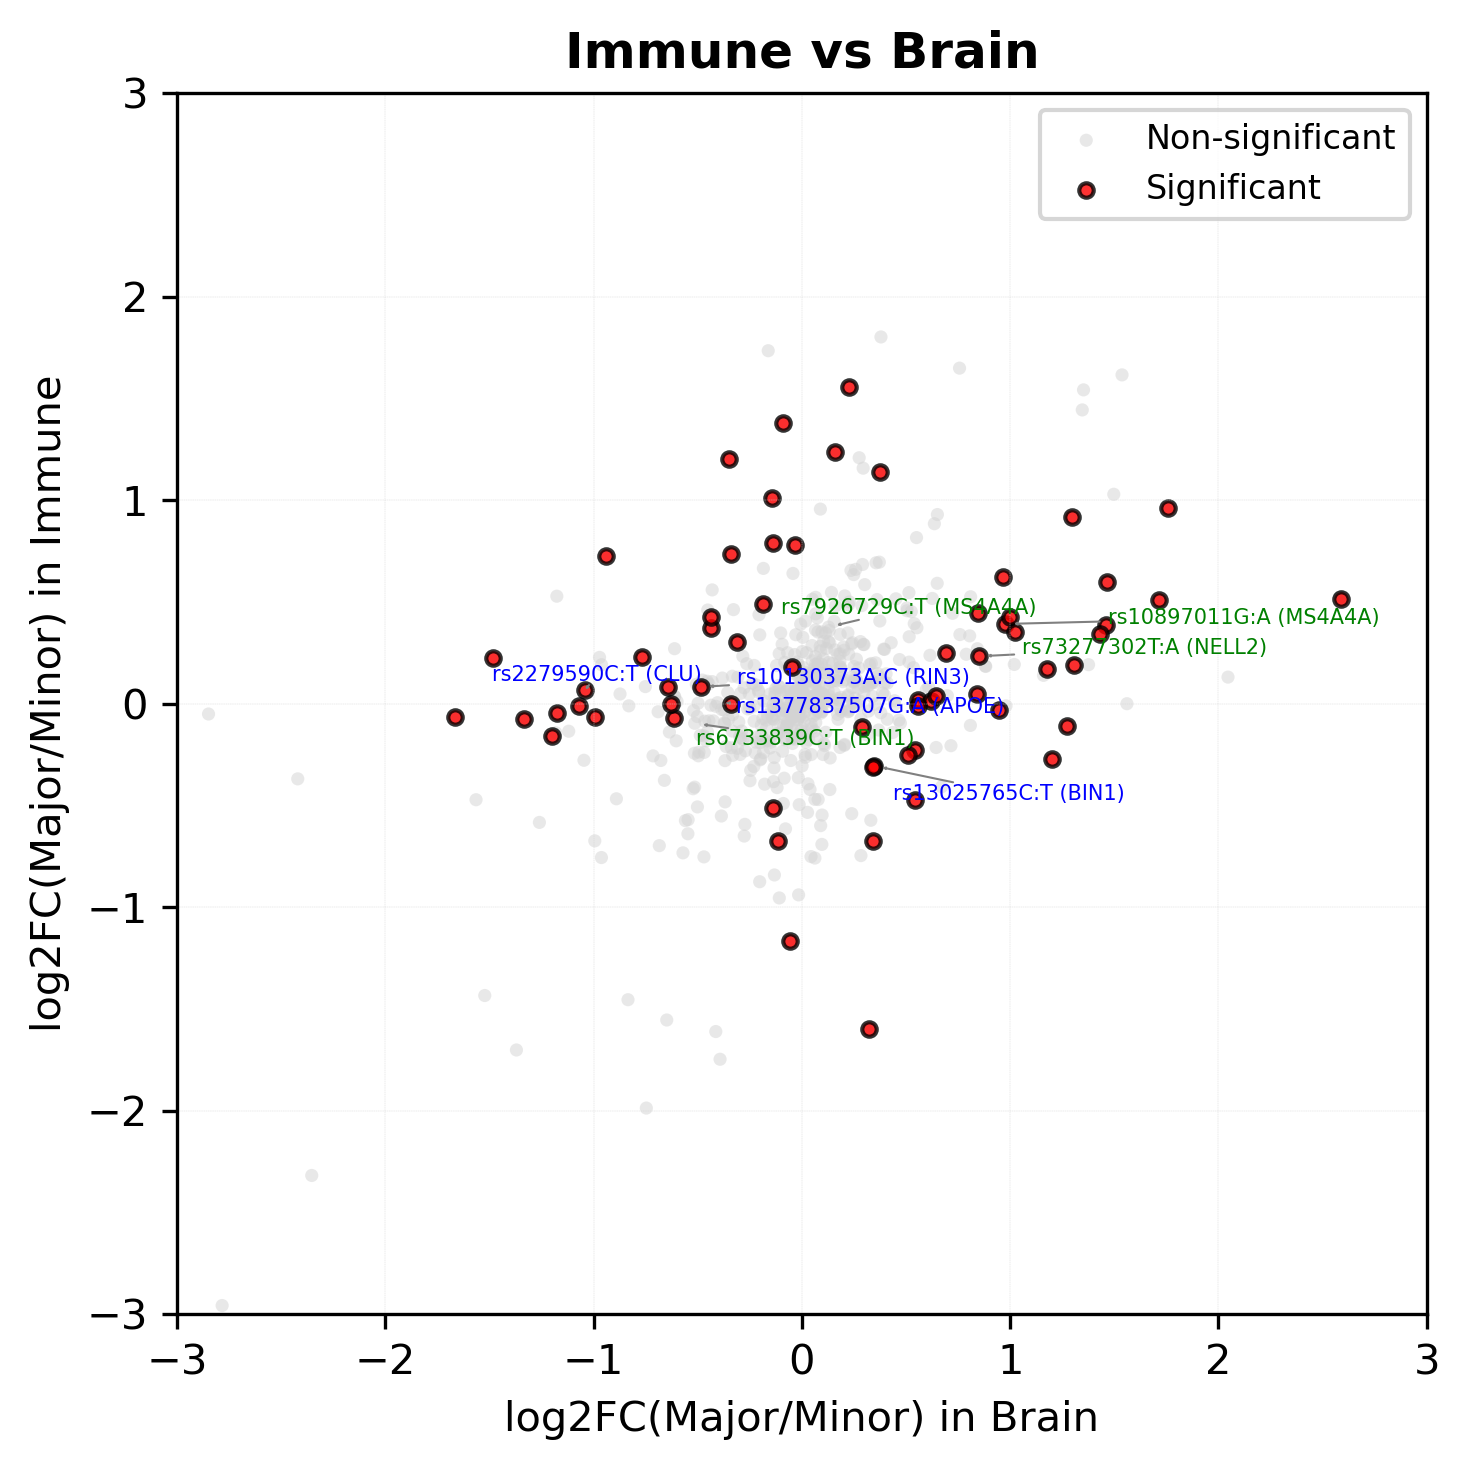

In [26]:
from adjustText import adjust_text
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
df_cluster = pd.read_csv( ('/media/zihengc/T7/THP1_machinelearning/prediction/allele_differences_genomic_mpra/majorminor_logFC.csv'),index_col=0)

df_cluster = pd.merge(df_cluster,df_haploreg[['rsid_protein_coding_gene','rsID']],left_index=True,right_index=True).drop_duplicates('rsID')
# Merge df_cluster with results_df to include adjusted p-values and significance
df_merged = df_cluster.merge(
    results_df[['Adj_PValue', 'Significant']],
    left_index=True, right_index=True
)

# Highlight significant SNPs
significant_points_index = df_merged[df_merged['Significant']].index

# Calculate mean values for plotting
x_mean = df_merged.iloc[:, 0:4].mean(axis=1)
y_mean = df_merged.iloc[:, 4:10].mean(axis=1)

# Create a scatter plot
plt.figure(figsize=(5, 5), dpi=300)

# Plot non-significant SNPs
plt.scatter(
    x_mean,
    y_mean,
    alpha=0.5, c='lightgrey', label='Non-significant', edgecolor='none', s=10
)

# Plot significant SNPs
plt.scatter(
    x_mean[significant_points_index],
    y_mean[significant_points_index],
    alpha=0.8, c='red', label='Significant', edgecolor='black', s=12
)

extreme_y =[
            'alt:rs10897011:PEAKCENTER:chr11:59961427:G:A:59961097:59961705:59961314',
            'alt:rs73277302:PEAKCENTER:chr12:44816820:T:A:44816212:44817154:44816763','alt:rs6733839:PEAKCENTER:chr2:127892810:C:T:127891990:127893319:127892710',
            #'alt:rs565199176:SNPCENTER:chr12:45104998:A:G:45104885:45105111:45104998','alt:rs17069127:SNPCENTER:chr6:108002600:A:G:108002487:108002713:108002600',
            'alt:rs7926729:PEAKCENTER:chr11:59961786:C:T:59961513:59962013:59961763',
            ]


extreme_x =['alt:rs2279590:PEAKCENTER:chr8:27456253:T:C:27456027:27456396:27456235','alt:rs1377837507:PEAKCENTER:chr19:44905959:G:A:44905547:44906127:44906017',
            'alt:rs13025765:PEAKCENTER:chr2:127128657:C:T:127128420:127128920:127128670',#'alt:rs1450550:PEAKCENTER:chr12:44816350:G:T:44816212:44817154:44816423',
            'alt:rs10130373:PEAKCENTER:chr14:92466231:C:A:92465994:92466494:92466244']
# Annotate extreme points
texts = []
for idx in extreme_x:
    texts.append(plt.text(x_mean[idx], y_mean[idx], df_merged.loc[idx]["rsid_protein_coding_gene"], fontsize=5, color='blue'))
for idx in extreme_y:
    if idx not in extreme_x:
        texts.append(plt.text(x_mean[idx], y_mean[idx], df_merged.loc[idx]["rsid_protein_coding_gene"], fontsize=5, color='green'))

# Automatically adjust text positions to prevent overlap
adjust_text(
    texts,
    arrowprops=dict(arrowstyle="->", color='gray', lw=0.5),  # Add arrows for clarity
)

# Add gridlines for better readability
plt.grid(color='lightgray', linestyle='--', linewidth=0.1)

# Set plot limits
plt.xlim(-3, 3)
plt.ylim(-3, 3)

# Add labels, title, and legend
plt.xlabel('log2FC(Major/Minor) in Brain', fontsize=10)
plt.ylabel('log2FC(Major/Minor) in Immune', fontsize=10)
plt.title('Immune vs Brain', fontsize=12, weight='bold')
plt.legend(frameon=True, fontsize=8)

# Tighten layout and save the plot
plt.tight_layout()
plt.savefig('scatter_plot_MousevsTHP1_labeled_adjusted.pdf', dpi=300, bbox_inches='tight')
plt.show()
